# Download and prepare `SWC` for the `FF1` soil profile (2004-2025)

**notebook version**: `1` (22 Jul 2026)

## ℹ️ About this notebook

Downloads the five screened soil-water-content series of the **`FF1` profile**, splices the two
sensor generations that share each depth's field name, corrects two defects the old screening left
behind, and writes one product to the external data folder.

Last of the `30_PRODUCTS/` notebooks, and the only one whose target is a **profile** rather than a
single series: a soil-moisture depth is only interpretable next to the ones above and below it.

::: {.callout-important title="Every depth's field name spans two different sensor sets"}
`SWC_FF1_<depth>_1` is **not one instrument**. Until 2018-2020 it is the old **EC-20 / "M5"**
profile, screened with the deprecated MeteoScreeningTool; from 10 Apr 2020 it is the **TEROS 12**
profile installed on 19 Mar 2020, screened in `20_SCREENING/SWC/`.

The two never overlap at any depth, and between them the record steps up by **+8 to +11 % VWC**,
seasonally varying. That step is measured below. It is real, and it is **not corrected in the
measured columns**.
:::

**Output columns** — three per depth, two at 0.5 m, grouped so a depth's value, its homogenised twin
and its provenance stay together:

- `SWC_FF1_<d>_1` — volumetric soil water content in **% VWC**, exactly as screened; gaps are `NaN`
- `SWC_FF1_<d>_1_HOMOGENIZED` — the same series with the non-TEROS eras shifted onto the TEROS level
  by additive calendar-month offsets. A **derived estimate**, not a measurement. Exists for
  0.05 / 0.1 / 0.2 / 0.3 m only
- `FLAG_SWC_FF1_<d>_1_SOURCE` — `0` no measurement, `1` EC-20 / M5, `2` TEROS 12 FF1, `3` TEROS 12
  replacement probe 40 cm downslope (0.3 m only); see `FLAG_SOURCE_LEGEND`

**Nothing is gap-filled.** No soil-moisture reference exists anywhere near this plot, and the
largest gaps are the year-long inter-era gaps of dying probes.

Downloading uses diive's `InfluxIO`, which needs `influxdb-client` from the `diive[db]` extra.

***

## 📇 Data sources

### The two profiles behind one set of names

| era | instrument | installed | screening | data version | depths |
|---|---|---|---|---|---|
| 1 | **EC-20**, the "M5" profile | before 2004 | MeteoScreeningTool | `meteoscreening_mst` | 0.05 / 0.1 / 0.2 / 0.3 |
| 2 | **TEROS 12**, the `FF1` profile | 19 Mar 2020 | diive | `meteoscreening_diive` | 0.05 / 0.1 / 0.2 / 0.3 / 0.5 |
| 3 | **TEROS 12**, replacement probe 40 cm downslope | 4 Mar 2025 | diive | `meteoscreening_diive` | 0.3 only |

: The three sensor eras hiding behind the `SWC_FF1_*` field names. {#tbl-eras}

Era 1 is stored under the `FF1` names although it is the M5 profile.
`20_SCREENING/SWC/SWC_FF1_0.2_1_2020-2025.ipynb` settles that at 0.2 m — the one depth where both
names exist in the database over the same period, Jan-Apr 2020: the two columns agree to four
decimal places, r = 0.998. The identification rests on those months and is extended to 2004. Era 1
therefore has four depths; **there is no 0.5 m before 2020**, and none is invented here.

Era 3 exists at 0.3 m only and is a different hole in the ground: the original probe could not be
pulled out, so its replacement went in about 40 cm **down the slope**.

### Deliberately ignored

- **`SWC_FF1_<d>_2`** — not a second sensor, but the old tool re-screening the same TEROS series
  (2020-2021, `mst` only). It is 99.98 % identical to replicate `1` and carries one record at
  exactly 100x the true value.
- **`SWC_FF3_*`** — a different profile, raw only, from Mar 2026.
- **`SWC_F_MDS_*`** — FLUXNET's gap-filled soil moisture, which already splices these two eras with
  the step passed straight through.

### Fieldbook

`CH-LAE-laegeren-export_20260719.csv`, read below (see `FIELDBOOK`). It supplies the installation
dates, the probe serial numbers, the logger rebuild and the replacement of the 0.3 m probe. For the
EC-20 era it also holds what a date filter cannot see: **the whole 2006-2011 site record is pasted
inside one row**, dated 2011-06-03, which is parsed separately below.

Legend: mst = screened with the deprecated MeteoScreeningTool; diive = screened with
[diive](https://github.com/holukas/diive).

## ⚠️ Two sensor sets under one name

Every other notebook in `30_PRODUCTS/` exports a quantity measured by one instrument, or by two
instruments proven to be the same series. This one cannot.

**The eras do not overlap, at any depth.** Each EC-20 stopped when it died; the TEROS profile
started reporting on 10 Apr 2020, weeks to months later. The interval between them runs from 22 days
(0.2 m) to 465 days (0.1 m) and is not an outage — it is the wait between one sensor failing and its
successor being wired up. The fieldbook's removal entry of 19 Mar 2020 says as much: by then only
the 0.2 m EC-20 was still running.

**Three consequences, worst first.**

1. **The step across the break is 8-11 % VWC and is not weather.** Absolute soil water content
   before and after 2020 is not comparable. A trend, drought index or water balance computed
   straight through the break is dominated by the probe change.
2. **The homogenisation offered here is weaker than notebook `08`'s.** `08` could rescale one
   precipitation era onto the other because an independent gauge measured through the break. Here
   **nothing measured through the break** — not the tower, not MeteoSwiss, not anybody. The offsets
   come from *climatology alone*, which assumes 2004-2019 and 2020-2025 had the same monthly
   soil-moisture means.
3. **The old probes were degrading for years before they died.** The GIN inventory flags three of
   the four EC-20s as `DEFECTIVE`, and that drift sits inside the era-1 climatology the offsets are
   fitted to.

::: {.callout-important title="What the _HOMOGENIZED columns are for, and what they are not for"}
**Use them for** continuity and trend work that must cross 2020 — anomalies, seasonal cycles,
correlations against flux or meteorology; anything where a constant per-month level error is what
you are trying to remove.

**Do not use them for** absolute soil water content before 2020. A homogenised 2008 value is a 2008
EC-20 reading shifted by a number derived from 2020-2025 TEROS climatology. It is not what the soil
held in 2008, and it is not a calibration.

For the plain measured record, take the `SWC_FF1_<d>_1` columns and filter on the source flag.
:::

Notebook `08` faced the same shape of problem and could answer *which era is right* with thirteen
independent stations. Here that question **cannot be answered at all**. The TEROS era is the
reference level because it is the modern, diive-screened, still-running one — not because anything
establishes it as correct.

## ⏱️ Timestamp convention

The database stores UTC `TIMESTAMP_END`. On download `InfluxIO` shifts by
`TIMEZONE_OFFSET_TO_UTC_HOURS` to local time, still `TIMESTAMP_END`;
`TimestampSanitizer(output_middle_timestamp=True)` then converts to `TIMESTAMP_MID` and **raises**
if the data are not 30MIN. Everything below works on `TIMESTAMP_MID`. `START` and `STOP` are read in
the same timezone as the offset.

::: {.callout-note title="Timestamps quoted from a screening notebook do not line up here"}
The five `20_SCREENING/SWC/` notebooks stay on `TIMESTAMP_END` throughout, because
`StepwiseMeteoScreeningDb` converts internally and hands back `TIMESTAMP_END` ready for upload. Any
timestamp taken from one of them is therefore a **`TIMESTAMP_END` in the raw high-resolution
record**.

The offset is **not only the half-hour**. A screened 30MIN record can end *earlier* than the raw
record it was built from: where the last raw records are too sparse or irregular to form a
resolution group, diive discards them and they never reach a 30MIN mean. At 0.3 m that difference is
33 hours — raw last value `2024-04-11 01:46`, this product's last value `2024-04-09 16:45`. Every
date quoted below is the product's, derived from the exported data.
:::

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'

# --- The exported profile ------------------------------------------------------------------
# One notebook for five depths, because a soil-moisture depth is only interpretable next to the
# ones above and below it. Field names are the database names, unchanged: which sensor generation
# produced a value is in the flag, not in the column name.
PROFILE = 'FF1'
REPL = '1'
DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
BUCKET = 'ch-lae_processed'
MEASUREMENT = 'SWC'


def field(depth: str) -> str:
    """The InfluxDB field name of one depth of this profile."""
    return f'SWC_{PROFILE}_{depth}_{REPL}'


def flagcol(depth: str) -> str:
    return f'FLAG_{field(depth)}_SOURCE'


def homogcol(depth: str) -> str:
    return f'{field(depth)}_HOMOGENIZED'


FIELDS = [field(d) for d in DEPTHS]

# The record starts with the first EC-20 measurement, not on 1 January 2004: there is no soil
# moisture before it and none is invented, so - as in notebook 05 - the index does not begin at
# the start of the year. Asserted against the downloaded data below.
RECORD_START = '2004-09-07'
RECORD_END = '2025-12-31'

# --- The 0.3 m sensor swap -----------------------------------------------------------------
# 0.3 m, and only 0.3 m, carries a THIRD era: the original probe stopped communicating in April
# 2024 and was replaced by a probe set ~40 cm down the slope, in different soil.
#
# That failure has TWO boundary dates and they are not the same. In the RAW record the probe's last
# value is 2024-04-11 01:46 and the dead period is 327 days; in the SCREENED 30MIN record this
# product reads, the last value is 33 hours earlier and the gap is 328 days, because the failing
# probe's final records are irregular stragglers and diive drops resolution groups holding less
# than 0.2 % of the record. Nothing was removed by hand - REMOVE_DATES is empty at this depth.
# The product's boundary is derived below and is what every date in this notebook refers to.
SWAP_DEPTH = '0.3'
SENSOR_SWAP = '2025-03-04'  # first day of the replacement probe
RAW_OLD_PROBE_LAST = '2024-04-11 01:46:00'   # raw TIMESTAMP_END, printed for comparison only
RAW_NEW_PROBE_FIRST = '2025-03-04 14:36:00'  # ditto - never used to slice

# --- The FF-A / FF-B file-group seam in the mst era -----------------------------------------
# The MeteoScreeningTool wrote the pre-2020 record in two file groups, FF-A (2004-2016) and
# FF-B (2017-2020), and both emit a record for this one timestamp. InfluxIO resolves the duplicate
# on download by keeping the last; the values agree to ~4 dp, so the choice is immaterial - but it
# is checked rather than assumed (see "The FF-A / FF-B seam").
MST_SEAM_UTC = '2016-12-31 23:00:00'

# Output: data files live in the external (untracked) data folder, with the same numeric prefix as
# this notebook. No verb and no GAPFILLED in the name, because nothing is filled.
OUTNAME = "09_METEO_SWC_FF1_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Fieldbook: the GIN export for this site. Read here rather than quoted from memory, so the device
# history below is re-derived when a newer export replaces this one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Physical plausibility of volumetric soil water content at this site, in %. Generous on purpose:
# it only has to catch a unit or gain error, not weather. Saturation of this soil is nowhere near
# 60 %, and 0 is the hard floor - a value below it is a failed sensor read, not dry soil.
SWC_PLAUSIBLE_PCT = (0.0, 60.0)

# --- Homogenisation knobs -------------------------------------------------------------------
# Additive calendar-month offsets fitted on the season-matched monthly means of each era. A month
# is fitted only where BOTH eras carry at least this many 30MIN records; months below the threshold
# inherit the mean of the fitted months, and an era with fewer than HOMOG_MIN_MONTHS fittable
# months is refused outright.
HOMOG_MIN_RECORDS_PER_MONTH = 500   # ~11 days of 30MIN data
HOMOG_MIN_MONTHS = 6

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)


# --- Captions -------------------------------------------------------------------------------
# Tables are captioned ABOVE, figures BELOW. Captions state what the output shows and what it
# settles; the numbers stay in the output itself, so a caption cannot go stale on a re-run.
def tabcap(text: str, width: int = 100) -> None:
    """Print a table caption. Call immediately before the display() it belongs to."""
    print(textwrap.fill(f"Table — {text}", width) + "\n")


def figcap(fig, text: str, width: int = 125) -> None:
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    fig.supxlabel(textwrap.fill(f"Figure — {text}", width), fontsize=9, ha='left', x=0.005)


# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-25 02:06:28
diive version: v0.91.0


### 🏷️ The source flag

One flag per depth, one vocabulary for all five. The codes name a **sensor set** — not a
gap-filling model (`01`-`03`) and not a reconstruction (`04`) — so any code above `0` means *this
depth measured this value*.

- `0` — no measurement: a gap, or a time before this depth's record begins. **0.5 m is `0` for the
  whole of 2004-2020**, because the old profile had no 0.5 m probe
- `1` — the EC-20 / M5 profile. Comparable within itself, **not** with `2`/`3`
- `2` — the TEROS 12 `FF1` profile, and the reference level of the homogenisation
- `3` — 0.3 m only, from 4 Mar 2025: the replacement TEROS probe, 40 cm down the slope

`2` and `3` are kept apart because the **measured** column still steps at the 2025 probe swap. Only
the `_HOMOGENIZED` column removes that step, and the two codes are what keep it findable.

In [3]:
# Provenance flag. NOT the ISFILLED flag of notebooks 01-03, whose codes name the model that
# produced a value, and NOT the MISSING flag of notebook 04, which marks reconstruction: nothing
# here is modelled or reconstructed. It names the SENSOR SET, because the sensor sets are not
# interchangeable and the whole product hinges on telling them apart.
FLAG_SOURCE_LEGEND = {
    0: '0 = no measurement (gap, or before this depth\'s record begins)',
    1: '1 = EC-20 / M5 profile, MeteoScreeningTool screening (2004 -> the probe\'s own death)',
    2: '2 = TEROS 12 FF1 profile installed 19 Mar 2020, diive screening (from 2020-04-10)',
    3: '3 = TEROS 12 replacement probe, 40 cm downslope, diive screening (0.3 m only, from 2025-03-04)',
}
FLAG_NOT_MEASURED = 0
FLAG_EC20_MST = 1
FLAG_TEROS_DIIVE = 2
FLAG_TEROS_REPLACEMENT = 3

MEASURED_FLAGS = (1, 2, 3)      # codes that carry a measurement

# The eras, in the order they are spliced. Kept as data rather than as prose so the tables and the
# assertions below can loop over it.
ERA_NAMES = {FLAG_EC20_MST: 'EC-20 / mst',
             FLAG_TEROS_DIIVE: 'TEROS / diive',
             FLAG_TEROS_REPLACEMENT: 'TEROS replacement / diive'}

for _v in FLAG_SOURCE_LEGEND.values():
    print(_v)

0 = no measurement (gap, or before this depth's record begins)
1 = EC-20 / M5 profile, MeteoScreeningTool screening (2004 -> the probe's own death)
2 = TEROS 12 FF1 profile installed 19 Mar 2020, diive screening (from 2020-04-10)
3 = TEROS 12 replacement probe, 40 cm downslope, diive screening (0.3 m only, from 2025-03-04)


### 🧭 Helpers

Five helpers carry the parts of this notebook that could quietly do the wrong thing: redacting the
people the fieldbook names, reading its HTML, confirming the stored unit against the stored values,
refusing to splice two eras that overlap, and deriving the monthly offsets. Each **raises** rather
than returning something empty, mis-scaled or fitted on three records, and every failure path is
exercised in the next two cells.

In [4]:
# --- Fieldbook redaction --------------------------------------------------------------------
# The GIN fieldbook is also a personnel record: its entries name the people who did the work, and
# this notebook renders to a public page. Names are replaced at the single point every fieldbook
# string passes through on its way to being printed, so a print site added later is covered without
# anyone having to remember it.
#
# The map lives beside the export, OUTSIDE this repository, so the repo never carries a real name.
# Its path is derived from FIELDBOOK so the two cannot drift apart. Pseudonyms are stable and
# append-only, so re-running reproduces the same text.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')
UNMAPPED_REPORT = Path(FIELDBOOK).with_name('redact_unmapped.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map used to redact the fieldbook.

    Raises FileNotFoundError if the map is missing. That is the point: carrying on with redaction
    quietly disabled prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the fieldbook redaction map is missing: {path}. Without it the names the fieldbook "
            f"records would print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
ALLOWED_TERMS = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())

# Longest surface form first, which is not cosmetic: the map holds both a bare surname and a
# double-barrelled one that starts with it ('Lovelace' and 'Lovelace-Byron', to use names that
# belong to nobody here), and replacing the short form first would corrupt the long one. The
# boundaries are lookarounds rather than \b because some forms end in an initial ('A. Lovelace'),
# where \b does not match. Matching is case-sensitive: these are capitalised names, and a
# case-insensitive pass would eat ordinary words.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped person's name in a fieldbook string with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


# --- The unknown-name net ---------------------------------------------------------------------
# The map can only redact names it already knows; this catches the rest. After redaction, a token
# sitting in one of the two shapes that actually carry names - the author parenthesis entries are
# signed with, and bylines such as 'with X' or 'durch X' - and that is neither a known technical
# term nor an all-caps device code is a candidate name.
#
# Both shapes were measured against the whole export before being trusted: together they leave 54
# distinct tokens, every one technical. A third shape, any capitalised pair, was tried and
# REJECTED - it leaves 560 tokens, nearly all sentence starters and device names, which would bury
# the signal and train everyone to ignore the check.
#
# Candidates are never printed. An unmapped token is most likely a real name and an exception
# message is stored in a notebook like any other output, so the list goes beside the map and only
# the count is shown here.
_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
# A person is up to three capitalised words ('Ada Marie Lovelace'), and a parenthesis can list
# several. Matching only comma-separated single tokens was the first attempt and quietly matched
# almost nothing - '(Ada Lovelace)' is separated by a space - so the net passed by looking at
# nothing at all. The positive control below is what caught that.
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+('
               + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Stopping here is the point: the
    alternative is that person's name printing into a page that gets published.
    """
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in ALLOWED_TERMS:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        if write_report:
            UNMAPPED_REPORT.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {UNMAPPED_REPORT}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(ALLOWED_TERMS)} allowlisted terms)")
    return 0


# The net is only worth having if it fires. 'Ada Lovelace' is nobody at this site, so the control
# can spell her out without disclosing anything - and it writes no report, so the real one is not
# overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print('  OK, the unknown-name net fired on a name that is not in the map')
else:
    raise AssertionError('(!) the unknown-name net did not fire on an unmapped name - it is broken.')


def plaintext(s) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted.

    The export stores the body as HTML. Redaction happens on the way out, so no caller can obtain
    the raw text by accident.
    """
    flat = re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()
    return redact_people(flat)


def require_data(series: pd.Series, label: str) -> pd.Series:
    """Return the series, refusing to hand back one that carries no data at all.

    A renamed field or data_version returns an empty frame from the database, and an empty frame
    propagates through combine_first as a silent multi-year hole. So it is an error, not a result.
    """
    n = int(series.notna().sum())
    if n == 0:
        raise ValueError(f"{label}: no data at all. Check the field name and the data_version.")
    print(f"  {label:<34} n={n:>7,}   {series.first_valid_index()} -> {series.last_valid_index()}   "
          f"mean {float(series.mean()):5.2f} %")
    return series


def check_unit_tag(series: pd.Series, declared_unit: str, label: str,
                   expected_unit: str = '%', plausible=None, max_out_of_band: float = 0.01) -> int:
    """Confirm the database's unit tag against the magnitude of the values themselves.

    Soil water content is stored as % VWC in BOTH data versions, but they carry different `gain`
    tags (1 for mst, 100 for diive). That records what each era's own raw source needed - mst read
    % from a CSV, diive reads m3/m3 and multiplies - and says nothing about the stored values. Side
    by side it looks exactly like a factor-100 bug, so the values are checked directly and NOTHING
    is ever rescaled here.

    The band is tested on the 1st-99th percentile rather than min/max on purpose: one mst record
    genuinely contains a run of failed-read constants (see "Corrections"), and a bad tail must not
    be able to masquerade as a unit error. A real unit error moves the whole distribution. The
    count of out-of-band records is capped separately at `max_out_of_band` of the record.

    Raises ValueError if the tag is not `expected_unit`, if the bulk of the data falls outside the
    plausible band, or if more than `max_out_of_band` of the records do.
    """
    plausible = SWC_PLAUSIBLE_PCT if plausible is None else plausible
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{label}: no data, cannot check the unit.")
    if declared_unit != expected_unit:
        raise ValueError(f"{label}: the database declares '{declared_unit}', expected "
                         f"'{expected_unit}'. Refusing to guess - check the source.")
    lo, hi = plausible
    q_lo, q_hi = float(s.quantile(0.01)), float(s.quantile(0.99))
    if not (lo <= q_lo and q_hi <= hi):
        raise ValueError(f"{label}: declared '{declared_unit}' but the central 98 % of the values "
                         f"run {q_lo:,.3f}..{q_hi:,.3f}, outside the plausible {lo}..{hi} % VWC. "
                         f"That is a unit or gain error, not weather. Not exporting this.")
    n_out = int(((s < lo) | (s > hi)).sum())
    frac = n_out / len(s)
    if frac > max_out_of_band:
        raise ValueError(f"{label}: {n_out:,} of {len(s):,} records ({100 * frac:.2f} %) lie "
                         f"outside {lo}..{hi} % VWC - too many to be stray failed reads.")
    print(f"  {label:<38} unit tag '{declared_unit}'  p01..p99 {q_lo:6.2f}..{q_hi:6.2f} %  "
          f"median {float(s.median()):5.2f}  out of band {n_out:>4,} ({100 * frac:.3f} %)")
    return n_out


def assert_no_overlap(early: pd.Series, late: pd.Series, label: str) -> pd.Timedelta:
    """Refuse to splice two eras that both carry a value at the same timestamp.

    The premise of every splice below is that the old probe was already dead when the new one
    started. If that stopped being true, `combine_first` would silently prefer one era and the step
    measured further down would be measured across a mixture. Returns the gap between the two eras,
    which this notebook reports rather than hides.
    """
    a, b = early.dropna(), late.dropna()
    if a.empty or b.empty:
        raise ValueError(f"{label}: one of the two eras is empty, there is nothing to splice.")
    both = a.index.intersection(b.index)
    if len(both) > 0:
        raise ValueError(f"{label}: the two eras overlap at {len(both):,} timestamps "
                         f"({both[0]} -> {both[-1]}). The splice premise is broken.")
    if a.index[-1] >= b.index[0]:
        raise ValueError(f"{label}: the early era ends at {a.index[-1]}, after the late era starts "
                         f"at {b.index[0]}. Interleaved eras cannot be spliced by date.")
    return b.index[0] - a.index[-1]


def derive_monthly_offsets(source: pd.Series, reference: pd.Series, label: str,
                           min_records: int = None, min_months: int = None,
                           verbose: bool = True):
    """Additive calendar-month offsets that put `source` onto the level of `reference`.

        offset[m] = mean(reference in calendar month m) - mean(source in calendar month m)

    Season-matched by construction - January is compared with January - so the seasonal cycle
    cannot leak into the offset. A month is fitted only where BOTH series carry at least
    `min_records` records; the rest inherit the unweighted mean of the fitted months, which is also
    the single number quoted as "the step" for that depth.

    Raises ValueError if either series is empty or if fewer than `min_months` calendar months can
    be fitted: an offset fitted on a handful of records is worse than no offset, because it looks
    like one.

    Returns (12-row table, mean of the fitted offsets).
    """
    min_records = HOMOG_MIN_RECORDS_PER_MONTH if min_records is None else min_records
    min_months = HOMOG_MIN_MONTHS if min_months is None else min_months
    src, ref = source.dropna(), reference.dropna()
    if src.empty or ref.empty:
        raise ValueError(f"{label}: source or reference era is empty, cannot derive offsets.")

    # One pass per era via groupby, rather than twelve masked passes over the whole series.
    months = pd.Index(range(1, 13), name='month')
    src_g, ref_g = src.groupby(src.index.month), ref.groupby(ref.index.month)
    tab = pd.DataFrame({'n_source': src_g.size().reindex(months, fill_value=0),
                        'n_reference': ref_g.size().reindex(months, fill_value=0),
                        'mean_source': src_g.mean().reindex(months),
                        'mean_reference': ref_g.mean().reindex(months)})
    tab['fitted'] = (tab['n_source'] >= min_records) & (tab['n_reference'] >= min_records)
    tab['offset'] = (tab['mean_reference'] - tab['mean_source']).where(tab['fitted'])

    n_fitted = int(tab['fitted'].sum())
    if n_fitted < min_months:
        raise ValueError(
            f"{label}: only {n_fitted} of 12 calendar months have at least {min_records:,} records "
            f"in both eras, need {min_months}. Refusing to homogenise on that.")
    fallback = float(tab.loc[tab['fitted'], 'offset'].mean())
    tab['offset'] = tab['offset'].fillna(fallback)
    if verbose:
        print(f"  {label:<44} {n_fitted:>2}/12 months fitted   offsets "
              f"{tab['offset'].min():+.2f} .. {tab['offset'].max():+.2f}   "
              f"mean {fallback:+.2f} % VWC")
    return tab, fallback

  OK, the unknown-name net fired on a name that is not in the map


#### The guards actually guard

Every failure path is exercised against deliberately bad input. If either cell below prints anything
other than a caught `ValueError`, do not trust the rest of the notebook.

In [5]:
_idx = pd.date_range('2020-01-01 00:15', periods=6 * 48 * 30, freq='30min')
_good = pd.Series(np.linspace(20, 30, len(_idx)), index=_idx)

# 1) require_data: an all-NaN series.
try:
    require_data(pd.Series(np.nan, index=_idx), 'negative control (all NaN)')
except ValueError as exc:
    print(f"OK, require_data raised for an all-NaN series: {exc}")
else:
    raise AssertionError("(!) require_data accepted an all-NaN series - the guard is broken.")

# 2) check_unit_tag: a wrong unit tag, and values that are 100x off (the exact shape the
#    differing `gain` tags would take if they really were a bug).
for _series, _unit, _why in [(_good, 'm3/m3', "a unit tag that is not '%'"),
                             (_good * 100, '%', 'values 100x too large'),
                             (pd.Series(np.nan, index=_idx), '%', 'a series with no data')]:
    try:
        check_unit_tag(_series, _unit, 'negative control')
    except ValueError as exc:
        print(f"OK, check_unit_tag raised for {_why}: {str(exc)[:120]}")
    else:
        raise AssertionError(f"(!) check_unit_tag accepted {_why} - the guard is broken.")

# 3) assert_no_overlap: two eras that share timestamps.
try:
    assert_no_overlap(_good, _good, 'negative control (identical eras)')
except ValueError as exc:
    print(f"OK, assert_no_overlap raised for overlapping eras: {str(exc)[:120]}")
else:
    raise AssertionError("(!) assert_no_overlap accepted overlapping eras - the guard is broken.")

# 4) load_redactions / redact_people: a map that is not there, and a name that is. Neither the
#    assertion messages nor the printed line may contain a real name, so the probe is checked
#    against the map rather than shown.
try:
    load_redactions(REDACT_MAP.with_name('no_such_redaction_map.csv'))
except FileNotFoundError as exc:
    print(f"OK, load_redactions raised for a missing map: {str(exc)[:120]}")
else:
    raise AssertionError("(!) load_redactions accepted a missing map - the guard is broken.")

_probe = next(iter(REDACTIONS))
_redacted = redact_people(f"fieldbook entry written by {_probe} on site")
assert _probe not in _redacted, "(!) redact_people left a mapped name in the text - guard broken."
assert REDACTIONS[_probe] in _redacted, "(!) redact_people did not insert the pseudonym."
print(f"OK, redact_people replaced a mapped name with its pseudonym "
      f"({len(REDACTIONS):,} surface forms loaded)")


OK, require_data raised for an all-NaN series: negative control (all NaN): no data at all. Check the field name and the data_version.
OK, check_unit_tag raised for a unit tag that is not '%': negative control: the database declares 'm3/m3', expected '%'. Refusing to guess - check the source.
OK, check_unit_tag raised for values 100x too large: negative control: declared '%' but the central 98 % of the values run 2,010.000..2,990.000, outside the plausible 0.0..6
OK, check_unit_tag raised for a series with no data: negative control: no data, cannot check the unit.
OK, assert_no_overlap raised for overlapping eras: negative control (identical eras): the two eras overlap at 8,640 timestamps (2020-01-01 00:15:00 -> 2020-06-28 23:45:00)
OK, load_redactions raised for a missing map: the fieldbook redaction map is missing: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\fieldb
OK, redact_people replaced a mapped name with its pseudonym (182 surface forms loaded)


In [6]:
# 4) derive_monthly_offsets: an era with too few CALENDAR MONTHS, and an era whose months are
#    all too thin. Both are ways of fitting a 12-parameter correction on nothing.
_full = pd.Series(np.random.default_rng(0).normal(30, 2, 2 * 365 * 48),
                  index=pd.date_range('2021-01-01 00:15', periods=2 * 365 * 48, freq='30min'))
_three_months = _full.loc['2021-01-01':'2021-03-31']                     # only 3 calendar months
_thin = _full.iloc[::400]                                                # 12 months, ~90 records each

for _src, _why in [(_three_months, 'an era covering only 3 calendar months'),
                   (_thin, 'an era whose every month is below the record threshold'),
                   (pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'an empty era')]:
    try:
        derive_monthly_offsets(_src, _full, 'negative control')
    except ValueError as exc:
        print(f"OK, derive_monthly_offsets raised for {_why}: {str(exc)[:140]}")
    else:
        raise AssertionError(f"(!) derive_monthly_offsets accepted {_why} - the guard is broken.")

# ... and it must still work on input that is actually fine, otherwise the guards above prove
# nothing except that the helper always raises.
_tab, _fb_off = derive_monthly_offsets(_full - 7.0, _full, 'negative control (valid input)')
assert abs(_fb_off - 7.0) < 0.5, "derive_monthly_offsets does not recover a known constant offset"
print(f"OK, derive_monthly_offsets recovers a known +7.0 offset as {_fb_off:+.3f}.")

OK, derive_monthly_offsets raised for an era covering only 3 calendar months: negative control: only 3 of 12 calendar months have at least 500 records in both eras, need 6. Refusing to homogenise on that.
OK, derive_monthly_offsets raised for an era whose every month is below the record threshold: negative control: only 0 of 12 calendar months have at least 500 records in both eras, need 6. Refusing to homogenise on that.
OK, derive_monthly_offsets raised for an empty era: negative control: source or reference era is empty, cannot derive offsets.
  negative control (valid input)               12/12 months fitted   offsets +7.00 .. +7.00   mean +7.00 % VWC
OK, derive_monthly_offsets recovers a known +7.0 offset as +7.000.


### 🔌 Connect to database

In [7]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## 📔 Fieldbook: the device history

The GIN export is read here rather than quoted from memory, so a newer export re-derives this
history instead of leaving a stale copy in the prose.

**The filter cannot be the soil device tag**, for two reasons both found the hard way: the entries
that explain the SWC gaps are power and logger entries carrying no soil device at all, and for the
pre-2020 era the words `Teros` and `SWC` return **nothing** — the old probes were filed as `SoilM`,
`MPS`, `decagon`, `EC-20` and, in one decisive entry, `multiplier`. The EC-20 identity appears only
in the device columns. The old record is also partly in German, so `Boden`, `Waldboden` and
`Bodenfeuchte` sit in the pattern next to `soil`. The filter therefore takes the operation tag
**or** the location **or** the device columns **or** the free text, and asserts it matched: an
export whose format changed silently returns zero rows, which reads exactly like "nothing ever
happened at this site".

**One row is held back and parsed separately.** The 2006-2011 site record was pasted into GIN as a
single entry of some 29,000 characters, dated the day it was pasted. Left in, it swamps every printout;
filtered by date, it is invisible in exactly the years that need it.

In [8]:
_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'
_fb['text'] = _fb['Text'].map(plaintext)
audit_unmapped_names(_fb['text'], 'fieldbook entries')

# The device columns are where the EC-20 identity lives; which of them an export carries has
# changed between exports, so whichever are present are concatenated.
_devcols = [c for c in ('Device Model', 'Device Name') if c in _fb.columns]
_fb['device'] = (_fb[_devcols].fillna('').astype(str).agg(' '.join, axis=1) if _devcols
                 else pd.Series('', index=_fb.index))

# The bulk row: the 2006-2011 legacy record, pasted in as one entry. Held out of `fb` and parsed in
# its own section below - its sub-entries carry their own dates INSIDE the text.
BULK_MARKER = r'old fieldbook entries'
_is_bulk = _fb['Text'].astype(str).str.contains(BULK_MARKER, case=False, na=False)
assert int(_is_bulk.sum()) >= 1, (
    f"(!) no row matching '{BULK_MARKER}' - the legacy 2006-2011 record is not in this export, or "
    f"its wording changed. Do not conclude those years are undocumented until this is checked.")

# Free text, both eras. `Teros|SWC` alone finds nothing before 2020; `SoilM|MPS|decagon|EC-20|
# multiplier` is what the old profile was filed under, and `Boden|Waldboden` is what it was called
# in German. `power|logger|SDI` catches the entries that explain the gaps but name no soil device.
_SOIL_TEXT = (r'soil|SWC|Teros|SDI|power supply|loggerprog|logger program|'
              r'SoilM|MPS|decagon|multiplier|EC-20|EC20|Waldboden|Bodenfeuchte|Boden')
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SWC|iDL_FF1|iDAQ_FF1', case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['device'].str.contains(r'EC-?20|Teros|decagon|MPS', case=False, na=False)
         | _fb['text'].str.contains(_SOIL_TEXT, case=False, na=False))
fb = (_fb[_mask & ~_is_bulk].drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))

assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f"fieldbook: {len(_fb):,} rows, {_fb['date'].min().date()} -> {_fb['date'].max().date()}")
print(f"bulk legacy row(s) held back for separate parsing: {int(_is_bulk.sum())}")
print(f"regular entries relevant to the soil profile, its logger or its power: {len(fb)}")


def fieldbook_near(start, stop=None, days: int = 2, maxchars: int = 420):
    """Print the fieldbook entries within `days` of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f"   (no fieldbook entry within +/-{days} days)")
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} [{str(r['Event Tag'])[:14]:<14s}] {r['text'][:maxchars]}")

  fieldbook entries: no unmapped name-shaped tokens (54 allowlisted terms)
fieldbook: 2,102 rows, 2003-10-24 -> 2026-07-17
bulk legacy row(s) held back for separate parsing: 1
regular entries relevant to the soil profile, its logger or its power: 222


### The entries this product stands on

Seven dates, each an era boundary, a resolution change or the explanation of a gap, printed from the
export rather than transcribed.

In [9]:
KEY_DATES = [
    ('2012-04-25', 'new FF logger program "with corrected multipliers and offset" - the ONLY '
                   'candidate gain change anywhere in the pre-2020 era, and it names no channels'),
    ('2020-03-19', 'five TEROS 12 installed; the old EC-20s removed the same day'),
    ('2020-04-10', 'logger script uploaded, first TEROS data, and the decision NOT to update the '
                   'CR1000 firmware for SDI-12 NaN support'),
    ('2020-04-21', 'two-byte precision'),
    ('2021-03-25', 'logger box rebuild: the raw resolution changes from 10MIN to 1MIN'),
    ('2024-04-23', '0.3 m unplugged - it had taken the whole FF1 SDI-12 port down with it'),
    ('2025-03-04', '0.3 m replacement probe, 40 cm down the slope'),
]
for _d, _why in KEY_DATES:
    print(f"\n--- {_d}  ({_why})")
    fieldbook_near(_d, days=2)


--- 2012-04-25  (new FF logger program "with corrected multipliers and offset" - the ONLY candidate gain change anywhere in the pre-2020 era, and it names no channels)
   2012-04-25 [FBA           ] 25.04.2012 (person 01) Changed wiring (CLK and RES) of the AM16-32 to the CR1000 to correct measuring connected TC(F&I), StemCO2(F&I) and SAPFlow(A) rearranged wires in the hut to the Logger and Moxa Downloaded CR10 data from the profile unit, disconnected CR10 and reconnnected to the CR1000 –> checked function Data download to moxa not yet installed Network to FF was not able. Restarted Bridge at FF and Acces Point 
   2012-04-27 [FBA           ] 27.04.2012 (person 02, person 27, person 01, person 12, person 71) cables from sap flow sensors and dendrometers were put in cable protectors (hut and forest floor) Installed new dendrometers (Huette: F,G,H,I,J,K,L, Waldboden: all old dendrometers replaced except Zweifel dendrometers. Should be trees A,B,C,D and F. E has a Zweifel dendrometer) co

### The legacy record, hidden inside one row

Filtering the export on its `Date` column says the site was silent from 2004 to mid-2011. **It was
not.** When GIN was introduced, the paper fieldbook of the preceding years was pasted in as a
**single row** — one date, one `FBA` event tag, and some 29,000 characters of text holding a hundred
dated sub-entries from 2006 to 2011.

This is a trap for every notebook in this repository. The sub-entries carry their dates **inside the
text** while the row carries the date it was pasted, so `fb['date'].between(START, STOP)` — the
idiom used everywhere — cannot see one of them, and a product covering 2004-2019 that filters by
date will wrongly conclude the record is empty.

Parsing it needs three things `plaintext()` does not do: `<br>` and closing block tags must become
**newlines** before tags are stripped, or the body collapses into one unreadable line; sub-entry
dates sit at the **start of a line**, sometimes in wiki emphasis (`==01.03.2011 (person 01)==`); and
the text is mixed German and English with **mojibake** (`Ã` for `Ü`/`Ö`), so patterns avoid umlauts.

Everything printed from the fieldbook carries a **stable pseudonym** (`person 01`, …) in place of a
name; see `redact_people()`.

In [10]:
def bulk_plaintext(s) -> str:
    """Like plaintext(), but preserves line structure. Redacts the people it names, as plaintext().

    The bulk row is a ~29 k-character paste in which every sub-entry begins on its own line. The
    ordinary tag strip turns that into a single line and destroys the only structure there is, so
    <br> and closing block tags become newlines BEFORE the tags are removed.
    """
    t = str(s)
    t = re.sub(r'(?i)<br\s*/?>', '\n', t)
    t = re.sub(r'(?i)</\s*(p|div|li|ul|ol|tr|table|h[1-6])\s*>', '\n', t)
    t = re.sub(r'<[^>]+>', ' ', t)
    t = html.unescape(t).replace('\xa0', ' ')
    t = re.sub(r'[ \t]+', ' ', t)
    return redact_people('\n'.join(ln.strip() for ln in t.split('\n')))


# A sub-entry starts with a dd.mm.yyyy date at the start of a line, possibly behind wiki emphasis
# or a bullet. The fallback pattern (used only if the line structure did not survive) accepts a
# date anywhere when it is followed by the author parenthesis these entries carry.
_SUB_ANCHORED = re.compile(r'(?m)^[\s=*\-•>]*((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})')
_SUB_LOOSE = re.compile(r'((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})(?=\s*[\(=])')


def split_legacy_entries(body: str, min_entries: int = 50) -> pd.DataFrame:
    """Split the pasted legacy fieldbook into its dated sub-entries.

    Raises ValueError if neither pattern finds at least `min_entries` dated sub-entries - a silent
    return of two or three would leave the notebook claiming those years are undocumented, which is
    exactly the wrong conclusion and the reason this row is parsed at all.
    """
    for _pat, _how in ((_SUB_ANCHORED, 'line-anchored'), (_SUB_LOOSE, 'loose')):
        hits = list(_pat.finditer(body))
        if len(hits) < min_entries:
            continue
        rows = []
        for i, m in enumerate(hits):
            end = hits[i + 1].start() if i + 1 < len(hits) else len(body)
            rows.append({'date': pd.to_datetime(m.group(1), format='%d.%m.%Y', errors='coerce'),
                         'text': re.sub(r'\s+', ' ', body[m.start():end]).strip()})
        out = pd.DataFrame(rows).dropna(subset=['date']).sort_values('date').reset_index(drop=True)
        if len(out) >= min_entries:
            print(f"  parsed with the {_how} pattern: {len(out)} dated sub-entries")
            return out
    raise ValueError(
        f"the legacy row did not split into at least {min_entries} dated sub-entries. Its HTML "
        f"structure has changed - fix bulk_plaintext() rather than concluding those years are "
        f"undocumented.")


# The guard actually guards: a body with no dates in it must raise, not return an empty frame.
try:
    split_legacy_entries('nothing dated in here at all')
except ValueError as exc:
    print(f"OK, split_legacy_entries raised for a body with no sub-entries: {str(exc)[:110]}")
else:
    raise AssertionError("(!) split_legacy_entries accepted a body with no dates - guard broken.")

BULK_ROW = _fb[_is_bulk].iloc[0]
BULK_BODY = bulk_plaintext(BULK_ROW['Text'])
audit_unmapped_names([BULK_BODY], 'legacy row')
print(f"\nbulk row: dated {BULK_ROW['date'].date()}, event tag '{BULK_ROW['Event Tag']}', "
      f"{len(str(BULK_ROW['Text'])):,} characters of HTML -> {len(BULK_BODY):,} of text")
LEGACY = split_legacy_entries(BULK_BODY)

print(f"legacy sub-entries: {len(LEGACY)}, "
      f"{LEGACY['date'].min().date()} -> {LEGACY['date'].max().date()}")
print(LEGACY['date'].dt.year.value_counts().sort_index().to_string())

assert len(LEGACY) >= 50, "too few legacy sub-entries parsed"
assert LEGACY['date'].min().year <= 2006 and LEGACY['date'].max().year >= 2011, \
    "the parsed legacy record does not span 2006-2011 - check the parse"


def legacy_search(pattern: str, maxchars: int = 420, limit: int = 12):
    """Print the legacy sub-entries whose text matches `pattern`."""
    hits = LEGACY[LEGACY['text'].str.contains(pattern, case=False, na=False, regex=True)]
    print(f"legacy sub-entries matching /{pattern}/: {len(hits)}")
    for _, r in hits.head(limit).iterrows():
        print(f"   {r['date']:%Y-%m-%d}  {r['text'][:maxchars]}")
    return hits

OK, split_legacy_entries raised for a body with no sub-entries: the legacy row did not split into at least 50 dated sub-entries. Its HTML structure has changed - fix bulk_pla
  legacy row: no unmapped name-shaped tokens (54 allowlisted terms)

bulk row: dated 2011-06-03, event tag 'FBA', 57,534 characters of HTML -> 29,170 of text
  parsed with the line-anchored pattern: 100 dated sub-entries
legacy sub-entries: 100, 2006-08-31 -> 2011-06-03
date
2006     3
2007    15
2008    22
2009     8
2010    37
2011    15


### What the legacy record says about the soil station

Three things, and the first two close gaps that would otherwise be unexplained.

The forest-floor station of this era ran on a **battery** — 12.4-12.7 V logged at nearly every visit
and the battery swapped repeatedly — so power dropouts are the *expected* failure mode of the
pre-2020 record. On **31.08.2010** soil instrumentation next to the station was re-buried, disturbing
the soil around the profile that day. The soil-moisture sensors "V1-V3" of 30.07.2010 belong to the
**FlipFlap respiration plot**, not to this profile.

::: {.callout-warning title="These are retro-added remarks, not contemporaneous entries"}
The two explanations that matter most were written **a year or more after the fact**, by someone
other than the original author. They match the data to the day, which is strong corroboration, but
they are weaker than an entry written on the day — and they are used below to *explain* gaps the
data found on their own, never to locate them.
:::

In [11]:
print("--- power supply of the forest-floor station ---")
_ = legacy_search(r'Batterie|battery|12\.\d\s*V|Volt', limit=6)

print("\n--- soil instrumentation disturbed ---")
_ = legacy_search(r'eingegraben|ausgegraben|Heat Flux Plate', limit=6)

print("\n--- the two entries that explain a data gap (matched against the data further below) ---")
_ = legacy_search(r'Sicherung|no forest floor logger data|doy\s*\d+', limit=6)

--- power supply of the forest-floor station ---
legacy sub-entries matching /Batterie|battery|12\.\d\s*V|Volt/: 8
   2007-11-13  13.11.2007 (person 07) CO2-Profile 14:00: new battery charger for profile unit Values of logger are OK now, except H2O values of logger CR10 are twice values on Li-7000 display THW-Profile 13:00 local time, new cable for wind sensor at 1m ' is running again
   2009-08-22  22.08.2009 (person 01) Phenocam 1 changed with the new System: New box installed Power supply modified now, without voltage controller and steady 12 V for the camera Problem to get a network connection because of the loose connection between lightning protection and camera. After rework on the cable the connection was possible. Cable connection not very stable'¨ longer network cable (camera ↔ lightning protection) n
   2010-01-12  12.01.2010 (person 01) Daten Waldbodenstation und Eddy abgeholt. Batteriespannung der Waldbodenstation ca. 12.7 V.'¨'¨Isocyclemessung mit LI-6262 abgebaut un

### What is documented, and what is not

- **2006-2025 is covered** once the bulk row is read: the legacy paste for 2006-2011, regular GIN
  entries from mid-2011.
- **2004 and 2005 are not covered at all.** The legacy record begins 31 Aug 2006 and the data begin
  7 Sep 2004, so the first two years are unadjudicable in principle.
- **Two months that matter are blank** even in the modern record: the month the 5 cm probe decouples
  and the month of the longest recent gap. Both are handled on physical evidence in the screening
  notebooks; a missing entry is not a veto.

In [12]:
_reg = _fb.loc[~_is_bulk, 'date']
_years_reg = _reg.dt.year.value_counts().reindex(range(2004, 2026), fill_value=0).sort_index()
_years_leg = (LEGACY['date'].dt.year.value_counts()
              .reindex(range(2004, 2026), fill_value=0).sort_index())
_doc = pd.DataFrame({'regular_rows': _years_reg, 'legacy_sub_entries': _years_leg})
_doc['total'] = _doc.sum(axis=1)
tabcap('site records per year, from the regular GIN rows and from the legacy row parsed above. '
       'Only the two years before the legacy record begins have no site record of any kind.')
display(_doc)

UNDOCUMENTED_YEARS = [int(y) for y in _doc.index[_doc['total'] == 0]]
print(f"years of this product with NO site record of any kind: {UNDOCUMENTED_YEARS}")
print(f"data start {RECORD_START}; earliest site record "
      f"{min(LEGACY['date'].min(), _reg.min()).date()}")

for _label, _period in [('the 5 cm probe decouples', '2020-08'),
                        ('the longest unexplained recent gap', '2024-06')]:
    _n = int((_reg.dt.to_period('M') == pd.Period(_period, 'M')).sum())
    print(f"regular entries in {_period} ({_label}): {_n}")

# The two claims the prose above makes, and nothing more. A quiet year in the middle of the
# record is a quiet year; a blank 2006-2011 would mean the legacy row failed to parse.
_early_blank = [y for y in UNDOCUMENTED_YEARS if y < 2006]
_legacy_blank = [y for y in UNDOCUMENTED_YEARS if 2006 <= y <= 2011]
assert _early_blank, ("this notebook claims 2004-2005 carry no site record; this export says "
                      "otherwise - re-read the section above before repeating it")
assert not _legacy_blank, (
    f"years {_legacy_blank} show as undocumented, which means the legacy row was not parsed - do "
    f"not repeat the claim that those years are empty")
print(f"\nUnadjudicable years, start of record: {_early_blank}. Everything from 2006 on has a site\n"
      f"record - provided the legacy row is read, which a date filter alone will never do.")

Table — site records per year, from the regular GIN rows and from the legacy row parsed above. Only
the two years before the legacy record begins have no site record of any kind.



,regular_rows,legacy_sub_entries,total
date,,,
2004,0,0,0
2005,0,0,0
2006,5,3,8
2007,0,15,15
2008,0,22,22
2009,0,8,8
2010,0,37,37
2011,16,15,31
2012,59,0,59


years of this product with NO site record of any kind: [2004, 2005]
data start 2004-09-07; earliest site record 2003-10-24
regular entries in 2020-08 (the 5 cm probe decouples): 0
regular entries in 2024-06 (the longest unexplained recent gap): 0

Unadjudicable years, start of record: [2004, 2005]. Everything from 2006 on has a site
record - provided the legacy row is read, which a date filter alone will never do.


***

## ⬇️ Download

Two downloads, one per data version, each over the whole range and each asking for all five depths.
Neither the era boundaries nor the depths present in each era are given to the query: which depth
exists in which data version is a fact about the record, read off the result below. A depth a data
version does not carry comes back missing and is filled in as an all-`NaN` column so the frames stay
rectangular.

The helper also **deduplicates explicitly**. `InfluxIO.download` already resolves duplicate
timestamps by keeping the last, which is how the FF-A / FF-B seam at the end of 2016 passes
unnoticed; `TimestampSanitizer` would not be so forgiving. Doing it here, with a printed count,
means the notebook says what happened instead of depending on a library default.

In [13]:
%%time


def download(fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=[MEASUREMENT], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    if data.empty:
        raise ValueError(f"{data_version}: the query returned nothing for {fields}.")

    # Explicit rather than implicit: InfluxIO keeps the last of a duplicated timestamp, which is
    # what silently absorbs the FF-A / FF-B seam. Report it, then do the same thing on purpose.
    n_dup = int(data.index.duplicated().sum())
    if n_dup:
        print(f"  ({data_version}) {n_dup} duplicated timestamp(s) survived the download: "
              f"{[str(t) for t in data.index[data.index.duplicated()][:5]]} - keeping the LAST")
        data = data[~data.index.duplicated(keep='last')]

    data = TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()

    # A depth the data version does not carry comes back as a missing column, not as an error.
    for f in fields:
        if f not in data.columns:
            print(f"  ({data_version}) no records at all for {f} - added as an empty column")
            data[f] = np.nan
    return data[fields]


mst = download(FIELDS, '2004-01-01 00:00:01', '2026-01-01 00:00:01', 'meteoscreening_mst')
diive_ = download(FIELDS, '2004-01-01 00:00:01', '2026-01-01 00:00:01', 'meteoscreening_diive')

print(f"\nmst   frame: {mst.shape[0]:,} rows x {mst.shape[1]} columns")
print(f"diive frame: {diive_.shape[0]:,} rows x {diive_.shape[1]} columns")

> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 
'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1'] from measurements ['SWC'], data version 
['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 
1)

> Downloaded data for 4 variables:

  (meteoscreening_mst) no records at all for SWC_FF1_0.5_1 - added as an empty column


> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 
'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1'] from measurements ['SWC'], data version 
['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to 
UTC 1)

> Downloaded data for 5 variables:


mst   frame: 272,229 rows x 5 columns
diive frame: 100,387 rows x 5 columns
CPU times: total: 25 s
Wall time: 35.2 s


### The record of each depth, per data version

The factual core of this notebook: where each sensor set starts, where it stops, and how long the
two are apart. Nothing is asserted in advance — the spans come from the data and the fieldbook is
asked afterwards whether it agrees. Read `gap_days` as **probe mortality, not downtime**: each EC-20
ends when *that* probe died, while the TEROS profile starts on one date for all five depths.

In [14]:
_rows = []
for d in DEPTHS:
    f = field(d)
    for _label, _frame in [('mst', mst), ('diive', diive_)]:
        s = _frame[f].dropna()
        _rows.append({'depth_m': float(d), 'data_version': _label, 'n': len(s),
                      'first': s.index[0] if len(s) else pd.NaT,
                      'last': s.index[-1] if len(s) else pd.NaT,
                      'mean_pct': round(float(s.mean()), 2) if len(s) else np.nan})
spans = pd.DataFrame(_rows).set_index(['depth_m', 'data_version'])
tabcap('first and last record of every depth in each data version. The mst record ends before the '
       'diive record begins at every depth, and 0.5 m has no mst record at all.')
display(spans)

# Which depths the old profile actually holds - read off the data, not declared in the settings.
MST_DEPTHS = [d for d in DEPTHS if mst[field(d)].notna().any()]
DIIVE_DEPTHS = [d for d in DEPTHS if diive_[field(d)].notna().any()]
print(f"depths present under mst:   {MST_DEPTHS}")
print(f"depths present under diive: {DIIVE_DEPTHS}")

assert DIIVE_DEPTHS == DEPTHS, "a depth is missing from the TEROS record - check the field names"
assert len(MST_DEPTHS) >= 4, (
    "fewer than four depths found in the mst record; the old M5 profile had four, so a field name "
    "or a data_version has changed")
_no_mst = [d for d in DEPTHS if d not in MST_DEPTHS]
print(f"\nno pre-2020 record at: {_no_mst} m - the old profile had no probe there, which is why "
      f"{_no_mst[0] if _no_mst else '-'} m gets no homogenised column further down.")

# The exported index must start where the record starts.
_first = min(mst[field(d)].first_valid_index() for d in MST_DEPTHS)
print(f"first measurement anywhere in the profile: {_first}")
assert _first.date() == pd.Timestamp(RECORD_START).date(), (
    f"RECORD_START is {RECORD_START} but the record starts on {_first.date()}")

Table — first and last record of every depth in each data version. The mst record ends before the
diive record begins at every depth, and 0.5 m has no mst record at all.



n               first                last  mean_pct
depth_m data_version                                                          
0.05    mst           207596 2004-09-07 13:45:00 2019-04-12 23:45:00     20.57
        diive          94462 2020-04-10 14:45:00 2025-12-31 23:45:00     29.88
0.10    mst           239457 2004-09-07 13:45:00 2018-12-31 23:45:00     19.86
        diive          98539 2020-04-10 14:45:00 2025-12-31 23:45:00     29.77
0.20    mst           260311 2004-09-07 13:45:00 2020-03-18 23:45:00     20.69
        diive          98552 2020-04-10 14:45:00 2025-12-31 23:45:00     31.23
0.30    mst           239424 2004-09-07 13:45:00 2019-11-08 23:45:00     18.92
        diive          83666 2020-04-10 14:45:00 2025-12-31 23:45:00     27.15
0.50    mst                0                 NaT                 NaT       NaN
        diive          98588 2020-04-10 14:45:00 2025-12-31 23:45:00     24.12

depths present under mst:   ['0.05', '0.1', '0.2', '0.3']
depths present under diive: ['0.05', '0.1', '0.2', '0.3', '0.5']

no pre-2020 record at: ['0.5'] m - the old profile had no probe there, which is why 0.5 m gets no homogenised column further down.
first measurement anywhere in the profile: 2004-09-07 13:45:00


### Units, `gain` and `offset`, straight from the database

Notebook `05` found two sources of one variable stored in different units and had to harmonise them.
Here the situation looks similar and **is not**. Both data versions are tagged `%` with
`offset = 0`, but they carry **different `gain` tags — `1` for `mst`, `100` for `diive`**.

That is a property of each era's raw source, not of the stored values: the MeteoScreeningTool read a
CSV already in %, diive reads the TEROS output in m³ m⁻³ and multiplies by 100. Both wrote % into
the database. Side by side in a tag table it looks precisely like a factor-100 bug — the single
worst thing this notebook could ship, because `29.9 %` and `0.299` are both plausible-looking
numbers. So the tag is checked against the **magnitude of the stored values**, per depth and per
data version, and nothing is rescaled anywhere.

In [15]:
def declared_tags(field_name, data_version):
    ov = dbc.show_field_overview(bucket=BUCKET, measurement=MEASUREMENT, field=field_name,
                                 data_version=data_version, verbose=False)
    return ov['tags'], ov

_rows = []
for d in DEPTHS:
    f = field(d)
    for _label, _dv, _frame in [('mst', 'meteoscreening_mst', mst),
                                ('diive', 'meteoscreening_diive', diive_)]:
        if _frame[f].notna().sum() == 0:
            continue
        _tags, _ov = declared_tags(f, _dv)
        _rows.append({'field': f, 'data_version': _label,
                      'units': '|'.join(_tags.get('units', [])),
                      'gain': '|'.join(_tags.get('gain', [])),
                      'offset': '|'.join(_tags.get('offset', [])),
                      'raw_units': '|'.join(_tags.get('raw_units', [])),
                      'filegroup': '|'.join(_tags.get('filegroup', [])),
                      'first_utc': _ov['first'], 'last_utc': _ov['last']})
TAGTAB = pd.DataFrame(_rows).set_index(['field', 'data_version'])
tabcap('the unit, gain and offset tags as stored in the database. Every record is tagged %, the '
       'gain differs between the two eras, and the raw_units column says why.')
display(TAGTAB)

print("\nThe unit tag against the values themselves (nothing is rescaled - see the helper):")
for (f, _label), _r in TAGTAB.iterrows():
    check_unit_tag(mst[f] if _label == 'mst' else diive_[f], _r['units'], f'{f} ({_label})')

print(f"\ndistinct gain tags in the product: {sorted(set(TAGTAB['gain']))}")
print("Different gains, identical units, identical magnitudes: the gain records what each era's\n"
      "own RAW source needed (mst read % from a CSV, diive reads m3/m3 and multiplies by 100).\n"
      "It is not a scaling difference between the stored series, and nothing is rescaled here.")

# Both tags arrive as strings, and a field can carry more than one value for a tag - they were
# '|'-joined above. So split them apart again, and compare the offset NUMERICALLY: InfluxDB stores
# it as '0.0', and asserting against the string '0' only tests how the tag was formatted.
_units = {_u for _v in TAGTAB['units'] for _u in _v.split('|') if _u}
_offsets = {float(_o) for _v in TAGTAB['offset'] for _o in _v.split('|') if _o}
assert _units == {'%'}, f"not every record is stored in %: {sorted(_units)}"
assert _offsets == {0.0}, f"a record carries a non-zero offset tag: {sorted(_offsets)}"

Table — the unit, gain and offset tags as stored in the database. Every record is tagged %, the gain
differs between the two eras, and the raw_units column says why.



units   gain offset    raw_units             filegroup            first_utc             last_utc
field          data_version                                                                                                 
SWC_FF1_0.05_1 mst              %  1.0|1    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2019-04-12 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.1_1  mst              %    1.0    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2018-12-31 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.2_1  mst              %  1.0|1    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2020-03-18 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.3_1  mst              %  1.0|1    0.0  -not-given-              10_meteo  2004-09-07 13:00:00  2019-11-08 23:00:00
               diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00
SWC_FF1_0.5_1  diive            %  100.0    0.0      m^3/m^3  12_meteo_forestfloor  2020-04-10 14:00:00  2025-12-31 23:00:00


The unit tag against the values themselves (nothing is rescaled - see the helper):
  SWC_FF1_0.05_1 (mst)                   unit tag '%'  p01..p99  11.08.. 30.32 %  median 20.51  out of band    0 (0.000 %)
  SWC_FF1_0.05_1 (diive)                 unit tag '%'  p01..p99  18.88.. 37.80 %  median 30.97  out of band    0 (0.000 %)
  SWC_FF1_0.1_1 (mst)                    unit tag '%'  p01..p99  10.58.. 27.59 %  median 19.80  out of band  690 (0.288 %)
  SWC_FF1_0.1_1 (diive)                  unit tag '%'  p01..p99  19.19.. 39.72 %  median 31.11  out of band    0 (0.000 %)
  SWC_FF1_0.2_1 (mst)                    unit tag '%'  p01..p99  12.31.. 28.91 %  median 20.66  out of band    0 (0.000 %)
  SWC_FF1_0.2_1 (diive)                  unit tag '%'  p01..p99  21.97.. 37.25 %  median 32.83  out of band    0 (0.000 %)
  SWC_FF1_0.3_1 (mst)                    unit tag '%'  p01..p99  10.93.. 25.67 %  median 19.61  out of band    0 (0.000 %)
  SWC_FF1_0.3_1 (diive)                  unit tag '%'  

### The FF-A / FF-B seam at the end of 2016

The MeteoScreeningTool wrote the pre-2020 record in two file groups — `FF-A` for 2004-2016, `FF-B`
for 2017-2020 — and for one timestamp, **2016-12-31 23:00 UTC**, both emit a record. Every mst depth
carries that duplicate.

It is harmless and is checked anyway, because *harmless* is a claim with two parts: that the two
records agree (they do, to about four decimal places, so which survives does not matter) and that
the series is continuous across the boundary (a tool switching input files is a classic place for a
level shift to hide). The download already removed the duplicate; what is verified below is that
exactly one record survived, that it is finite, and that the change across the seam is unremarkable
against this depth's own distribution of 30-minute changes.

In [16]:
# The seam in local TIMESTAMP_MID: UTC -> local TIMESTAMP_END -> minus 15 min.
SEAM_MID = (pd.Timestamp(MST_SEAM_UTC)
            + pd.Timedelta(hours=TIMEZONE_OFFSET_TO_UTC_HOURS)
            - pd.Timedelta(minutes=15))
print(f"file-group seam: {MST_SEAM_UTC} UTC  ->  {SEAM_MID} local TIMESTAMP_MID\n")

_rows = []
for d in MST_DEPTHS:
    s = mst[field(d)]
    _n_here = int((s.index == SEAM_MID).sum())
    _step = float(s.get(SEAM_MID, np.nan) - s.get(SEAM_MID - pd.Timedelta(minutes=30), np.nan))
    _typ = float(s.diff().abs().quantile(0.999))
    _rows.append({'depth_m': float(d), 'records_at_seam': _n_here,
                  'before': round(float(s.get(SEAM_MID - pd.Timedelta(minutes=30), np.nan)), 4),
                  'at_seam': round(float(s.get(SEAM_MID, np.nan)), 4),
                  'after': round(float(s.get(SEAM_MID + pd.Timedelta(minutes=30), np.nan)), 4),
                  'step': round(_step, 4), 'p99.9_of_|step|': round(_typ, 4)})
seam = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the values on either side of the FF-A / FF-B file-group boundary. One record survives per '
       'depth and the step across it is far below that depth\'s own p99.9 30-minute change.')
display(seam)

assert (seam['records_at_seam'] == 1).all(), "the FF-A / FF-B duplicate survived the download"
assert seam['at_seam'].notna().all(), "a depth has no value at the file-group seam"
assert (seam['step'].abs() <= seam['p99.9_of_|step|']).all(), (
    "the change across the FF-A / FF-B seam is larger than this depth's 99.9th percentile 30-min "
    "change - the two file groups may not be on one level")
print("One record per depth at the seam, and the step across it is ordinary. The file-group\n"
      "boundary is a bookkeeping detail, not a break in the measurement.")

file-group seam: 2016-12-31 23:00:00 UTC  ->  2016-12-31 23:45:00 local TIMESTAMP_MID

Table — the values on either side of the FF-A / FF-B file-group boundary. One record survives per
depth and the step across it is far below that depth's own p99.9 30-minute change.



,records_at_seam,before,at_seam,after,step,p99.9_of_|step|
depth_m,,,,,,
0.05,1,19.9854,19.9854,19.9854,0.0000,1.3500
0.10,1,16.8794,16.8786,16.8912,-0.0008,1.5900
0.20,1,17.8881,17.8885,17.8849,0.0004,1.2005
0.30,1,18.6437,18.6437,18.6437,0.0000,1.2728


One record per depth at the seam, and the step across it is ordinary. The file-group
boundary is a bookkeeping detail, not a break in the measurement.


***

## 🔗 Splice the two eras

### They cannot overlap, and that is asserted rather than assumed

Every other splice in this folder had to prove two records were *the same series* before joining
them. This one is the opposite: the two are emphatically **not** the same series, and what has to be
proven is that they never coincide.

`combine_first` is used rather than `concat`, as everywhere else in `30_PRODUCTS/`. Here it is worth
saying why the choice cannot matter: the eras are disjoint, so `combine_first` simply concatenates
them, and the cell below refuses to continue if that stops being true. Keeping it anyway means a
future re-screening that extended one era into the other would resolve deterministically instead of
duplicating timestamps — and `assert_no_overlap` would catch it first.

In [17]:
print("Gap between the two sensor sets, per depth:")
INTER_ERA_GAP = {}
for d in MST_DEPTHS:
    _gap = assert_no_overlap(mst[field(d)], diive_[field(d)], f'{field(d)}')
    INTER_ERA_GAP[d] = _gap
    print(f"  {field(d):<18} last EC-20 {mst[field(d)].last_valid_index()}  ->  "
          f"first TEROS {diive_[field(d)].first_valid_index()}   gap {_gap.days:>4} days")

print("\nNo depth has a single timestamp measured by both profiles. Every gap above is one probe\n"
      "dying before its successor was wired up - which is why none of them is filled.")

Gap between the two sensor sets, per depth:
  SWC_FF1_0.05_1     last EC-20 2019-04-12 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap  363 days
  SWC_FF1_0.1_1      last EC-20 2018-12-31 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap  465 days
  SWC_FF1_0.2_1      last EC-20 2020-03-18 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap   22 days
  SWC_FF1_0.3_1      last EC-20 2019-11-08 23:45:00  ->  first TEROS 2020-04-10 14:45:00   gap  153 days

No depth has a single timestamp measured by both profiles. Every gap above is one probe
dying before its successor was wired up - which is why none of them is filled.


### The 0.3 m sensor swap, located in the data

`SENSOR_SWAP` is a setting, and a setting is a claim. The cell below re-derives it from the largest
gap inside the TEROS era, then checks that against the settings and the fieldbook, so a re-screening
that moved the boundary fails loudly instead of mislabelling a year of the replacement probe as the
original one. It also prints the **raw** record's boundary beside the product's: the two differ by
33 hours, for the reason given under *Timestamp convention*.

In [18]:
_s03 = diive_[field(SWAP_DEPTH)].dropna()
_gaps = _s03.index.to_series().diff()
_biggest = _gaps.max()
_resumes = _gaps.idxmax()
_silent_from = _s03.index[_s03.index.get_loc(_resumes) - 1]
DEAD_PERIOD_DAYS = int(_biggest.days)

print(f"largest gap inside the TEROS era at {SWAP_DEPTH} m: {DEAD_PERIOD_DAYS} days")
print(f"  last record of the original probe: {_silent_from}   <- THIS PRODUCT's boundary")
print(f"  first record of the replacement:   {_resumes}")
print(f"  SENSOR_SWAP as configured:         {SENSOR_SWAP}")

assert _resumes.date() == pd.Timestamp(SENSOR_SWAP).date(), (
    f"the {SWAP_DEPTH} m record resumes on {_resumes.date()}, not on the configured "
    f"SENSOR_SWAP {SENSOR_SWAP} - the era split would be wrong")
assert _biggest.days > 180, (
    f"the largest gap at {SWAP_DEPTH} m is only {_biggest.days} days; the year-long dead period "
    f"this notebook splits on is not in the data")

# The raw record ends LATER than this product does. Both numbers are true, they describe different
# records, and they get quoted for each other unless something prints them side by side.
_raw_last, _raw_first = pd.Timestamp(RAW_OLD_PROBE_LAST), pd.Timestamp(RAW_NEW_PROBE_FIRST)
_tail_h = (_raw_last - _silent_from).total_seconds() / 3600
print("\nraw high-resolution record (TIMESTAMP_END, from the screening notebook):")
print(f"  last value of the original probe:  {_raw_last}  ({_tail_h:.1f} h later)")
print(f"  first value of the replacement:    {_raw_first}")
print(f"  raw dead period {(_raw_first - _raw_last).days} days, against the {DEAD_PERIOD_DAYS} days "
      f"this product carries.")
print("  The difference is the failing probe's irregular tail, dropped with the sub-0.2 %\n"
      "  resolution groups before resampling. Quote the product's boundary, not the raw one.")

assert _silent_from <= _raw_last, (
    f"the screened record ends at {_silent_from}, AFTER the raw record's last value {_raw_last} - "
    f"one of the two is wrong, and the raw one comes from the screening notebook")
assert pd.Timedelta(0) <= (_raw_last - _silent_from) < pd.Timedelta(days=5), (
    f"the screened record ends {_raw_last - _silent_from} before the raw one. That is more than a "
    f"failing probe's tail explains - find out what screening dropped before quoting either date")

print("\nThe fieldbook, asked afterwards:")
fieldbook_near(SENSOR_SWAP, days=1)

largest gap inside the TEROS era at 0.3 m: 328 days
  last record of the original probe: 2024-04-09 16:45:00   <- THIS PRODUCT's boundary
  first record of the replacement:   2025-03-04 14:45:00
  SENSOR_SWAP as configured:         2025-03-04

raw high-resolution record (TIMESTAMP_END, from the screening notebook):
  last value of the original probe:  2024-04-11 01:46:00  (33.0 h later)
  first value of the replacement:    2025-03-04 14:36:00
  raw dead period 327 days, against the 328 days this product carries.
  The difference is the failing probe's irregular tail, dropped with the sub-0.2 %
  resolution groups before resampling. Quote the product's boundary, not the raw one.

The fieldbook, asked afterwards:
   2025-03-04 [TRASHED       ] Device is broken. Could not be fixed. Will be left in the soil to not disturb other sensors
   2025-03-04 [HW_MOD        ] Replaced the old sensor in new spot. The old sensor could not be removed without disturbing the full soil profile
   2025-03-

### Merge onto one continuous 30MIN index

The index runs from the first EC-20 measurement to the end of 2025 and is continuous throughout;
where nothing measured, the value is `NaN` and the flag is `0`. The flag is written from the era
masks **in the order the sensors existed**, so a timestamp can only end up with the code of the
sensor that produced it. Nothing is written into gaps, so `notna()` and the flag are two views of
one fact from the start.

In [19]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
swc = pd.DataFrame(index=full_index)

print("Slices taken (each one must carry data):")
for d in DEPTHS:
    f = field(d)
    _era1 = mst[f].dropna()
    _era2 = diive_[f].dropna()

    # Nothing may fall off the edge of the exported index. reindex() would drop it in silence.
    for _s, _lbl in [(_era1, f'{f} (mst)'), (_era2, f'{f} (diive)')]:
        _outside = _s.index.difference(full_index)
        assert _outside.empty, (f"{_lbl}: {len(_outside):,} records lie outside the exported index "
                                f"({_outside[0]} ... {_outside[-1]}) - widen RECORD_START/END")

    if len(_era1):
        require_data(_era1, f'{f} (EC-20 / mst)')
    require_data(_era2, f'{f} (TEROS / diive)')

    swc[f] = _era1.combine_first(_era2).reindex(full_index)

    fl = pd.Series(FLAG_NOT_MEASURED, index=full_index, dtype=int)
    fl.loc[_era1.index] = FLAG_EC20_MST
    fl.loc[_era2.index] = FLAG_TEROS_DIIVE
    if d == SWAP_DEPTH:
        _new = _era2.index[_era2.index >= pd.Timestamp(SENSOR_SWAP)]
        fl.loc[_new] = FLAG_TEROS_REPLACEMENT
    swc[flagcol(d)] = fl

print(f"\nmerged frame: {len(swc):,} records, {swc.index[0]} -> {swc.index[-1]}")
tabcap('the merged frame - one value column and one source flag per depth, on a continuous 30MIN '
       'index from the first EC-20 record to the end of 2025.')
swc

Slices taken (each one must carry data):
  SWC_FF1_0.05_1 (EC-20 / mst)       n=207,596   2004-09-07 13:45:00 -> 2019-04-12 23:45:00   mean 20.57 %
  SWC_FF1_0.05_1 (TEROS / diive)     n= 94,462   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 29.88 %
  SWC_FF1_0.1_1 (EC-20 / mst)        n=239,457   2004-09-07 13:45:00 -> 2018-12-31 23:45:00   mean 19.86 %
  SWC_FF1_0.1_1 (TEROS / diive)      n= 98,539   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 29.77 %
  SWC_FF1_0.2_1 (EC-20 / mst)        n=260,311   2004-09-07 13:45:00 -> 2020-03-18 23:45:00   mean 20.69 %
  SWC_FF1_0.2_1 (TEROS / diive)      n= 98,552   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 31.23 %
  SWC_FF1_0.3_1 (EC-20 / mst)        n=239,424   2004-09-07 13:45:00 -> 2019-11-08 23:45:00   mean 18.92 %
  SWC_FF1_0.3_1 (TEROS / diive)      n= 83,666   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 27.15 %
  SWC_FF1_0.5_1 (TEROS / diive)      n= 98,588   2020-04-10 14:45:00 -> 2025-12-31 23:45:00   mean 24.1

,SWC_FF1_0.05_1,FLAG_SWC_FF1_0.05_1_SOURCE,SWC_FF1_0.1_1,FLAG_SWC_FF1_0.1_1_SOURCE,SWC_FF1_0.2_1,FLAG_SWC_FF1_0.2_1_SOURCE,SWC_FF1_0.3_1,FLAG_SWC_FF1_0.3_1_SOURCE,SWC_FF1_0.5_1,FLAG_SWC_FF1_0.5_1_SOURCE
TIMESTAMP_MIDDLE,,,,,,,,,,
2004-09-07 00:15:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 00:45:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 01:15:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 01:45:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 02:15:00,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,29.538065,2,30.736580,2,32.139789,2,30.388568,3,25.212793,2
2025-12-31 22:15:00,29.528240,2,30.735927,2,32.138521,2,30.382575,3,25.209556,2
2025-12-31 22:45:00,29.530094,2,30.733229,2,32.133453,2,30.378484,3,25.209057,2


### The splice is exact

Four ways a splice can go wrong, one assertion each: a value without provenance or the reverse, a
record lost or invented on the way in, an era block that is not where the era is, and a flag code
outside the vocabulary.

In [20]:
# 1) Value and flag agree everywhere, at every depth.
for d in DEPTHS:
    assert (swc[field(d)].notna() == swc[flagcol(d)].isin(MEASURED_FLAGS)).all(), \
        f"{field(d)}: a record has a value without a flag, or a flag without a value"
    assert swc[flagcol(d)].isin(FLAG_SOURCE_LEGEND).all(), \
        f"{flagcol(d)}: unknown code in the source flag"

# 2) Nothing lost, nothing invented: every downloaded record made it in exactly once.
for d in DEPTHS:
    _expected = int(mst[field(d)].notna().sum() + diive_[field(d)].notna().sum())
    _got = int(swc[field(d)].notna().sum())
    assert _got == _expected, f"{field(d)}: {_expected:,} records downloaded but {_got:,} merged"

# 3) Each era block sits where the era does.
_rows = []
for d in DEPTHS:
    for _code, _name in ERA_NAMES.items():
        _ix = swc.index[swc[flagcol(d)] == _code]
        if len(_ix):
            _rows.append({'depth_m': float(d), 'flag': _code, 'era': _name, 'n': len(_ix),
                          'first': _ix[0], 'last': _ix[-1]})
blocks = pd.DataFrame(_rows).set_index(['depth_m', 'flag']).sort_index()
tabcap('the extent of every sensor era at every depth. Each era ends before the next begins, and '
       '0.5 m carries only the TEROS era.')
display(blocks)

# Every CONSECUTIVE pair of eras, not just era 1 against the rest: at 0.3 m the 2 -> 3 boundary is
# the one a re-screening is most likely to move, so it is checked like any other.
for _d, _g in blocks.groupby(level='depth_m'):
    _last, _first = _g['last'].to_numpy()[:-1], _g['first'].to_numpy()[1:]
    assert (_last < _first).all(), \
        f"{_d} m: an era block reaches past the start of the era that follows it"

# 4) A depth with no pre-2020 probe is flagged 0 for that whole period, because there was no
#    instrument - which is a different statement from missing data.
_nomst = [d for d in DEPTHS if d not in MST_DEPTHS]
for d in _nomst:
    _pre = swc.loc[:diive_[field(d)].first_valid_index(), flagcol(d)].iloc[:-1]
    assert (_pre == FLAG_NOT_MEASURED).all(), f"{field(d)} carries a flag before the TEROS profile"
print(f"\nSplice verified. Depths without a pre-2020 probe ({_nomst} m) are flag 0 throughout that "
      f"period,\nwhich is the truthful statement: not missing data, but no instrument.")

Table — the extent of every sensor era at every depth. Each era ends before the next begins, and 0.5
m carries only the TEROS era.



era       n               first                last
depth_m flag                                                                           
0.05    1                   EC-20 / mst  207596 2004-09-07 13:45:00 2019-04-12 23:45:00
        2                 TEROS / diive   94462 2020-04-10 14:45:00 2025-12-31 23:45:00
0.10    1                   EC-20 / mst  239457 2004-09-07 13:45:00 2018-12-31 23:45:00
        2                 TEROS / diive   98539 2020-04-10 14:45:00 2025-12-31 23:45:00
0.20    1                   EC-20 / mst  260311 2004-09-07 13:45:00 2020-03-18 23:45:00
        2                 TEROS / diive   98552 2020-04-10 14:45:00 2025-12-31 23:45:00
0.30    1                   EC-20 / mst  239424 2004-09-07 13:45:00 2019-11-08 23:45:00
        2                 TEROS / diive   69152 2020-04-10 14:45:00 2024-04-09 16:45:00
        3     TEROS replacement / diive   14514 2025-03-04 14:45:00 2025-12-31 23:45:00
0.50    2                 TEROS / diive   98588 2020-04-10 14:45:00 2025-12-31 23:45:00


Splice verified. Depths without a pre-2020 probe (['0.5'] m) are flag 0 throughout that period,
which is the truthful statement: not missing data, but no instrument.


***

## 🔍 Measure the step

How big is the discontinuity, and what shape is it? Everything downstream — whether to homogenise at
all, additively or multiplicatively, with one offset or twelve — depends on the answer, so it is
measured before anything is decided.

Two preliminaries, because they change the numbers. The comparison is **season-matched**: era 1 runs
2004 to 2018-2020 and era 2 from 2020, and they do not cover the same months in the same
proportions, so every number below compares January with January. And the step is measured on values
inside the plausible band: one mst record carries a run of failed-read constants near −29 % VWC,
which would move that depth's December mean by more than a per cent. That is a defect, not a step;
the same band is applied for real in *Corrections* immediately below.

In [21]:
def era_series(depth, code, clean=True):
    """One depth's values belonging to one sensor era, optionally masked to the plausible band."""
    s = swc[field(depth)].where(swc[flagcol(depth)] == code)
    if clean:
        s = s.where(s.between(*SWC_PLAUSIBLE_PCT))
    return s.dropna()


def multi_era_depths() -> list:
    """Depths whose flag column currently carries more than one measured era.

    Derived from the flags rather than declared, and re-derived after the corrections below, so a
    depth that lost an era to screening cannot keep a homogenised column it no longer earns.
    """
    return [d for d in DEPTHS if len(set(swc[flagcol(d)].unique()) & set(MEASURED_FLAGS)) > 1]


STEP_DEPTHS = multi_era_depths()
print(f"depths with more than one sensor era: {STEP_DEPTHS} m")
print(f"depths with a single era (nothing to step): "
      f"{[d for d in DEPTHS if d not in STEP_DEPTHS]} m\n")

_rows = []
for d in STEP_DEPTHS:
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    m1 = e1.groupby(e1.index.month).mean()
    m2 = e2.groupby(e2.index.month).mean()
    _common = m1.index.intersection(m2.index)
    _rows.append({'depth_m': float(d), 'n_era1': len(e1), 'n_era2': len(e2),
                  'mean_era1': float(e1.mean()), 'mean_era2': float(e2.mean()),
                  'raw_difference': float(e2.mean() - e1.mean()),
                  'season_matched_step': float((m2[_common] - m1[_common]).mean()),
                  'ratio_era2_era1': float(e2.mean() / e1.mean())})
STEPTAB = pd.DataFrame(_rows).set_index('depth_m').round(3)
tabcap('the step between the two sensor sets, raw and season-matched. It is large and positive at '
       'every depth, and no implied ratio is near a round number, so it is not a unit or gain '
       'error that slipped past the tag check - it is two instruments in two different holes.')
display(STEPTAB)

print(f"season-matched step: {STEPTAB['season_matched_step'].min():+.2f} to "
      f"{STEPTAB['season_matched_step'].max():+.2f} % VWC across the four depths")
print(f"implied ratios:      {', '.join(f'{v:.3f}' for v in STEPTAB['ratio_era2_era1'])}")

depths with more than one sensor era: ['0.05', '0.1', '0.2', '0.3'] m
depths with a single era (nothing to step): ['0.5'] m

Table — the step between the two sensor sets, raw and season-matched. It is large and positive at
every depth, and no implied ratio is near a round number, so it is not a unit or gain error that
slipped past the tag check - it is two instruments in two different holes.



,n_era1,n_era2,mean_era1,mean_era2,raw_difference,season_matched_step,ratio_era2_era1
depth_m,,,,,,,
0.05,207596,94462,20.575,29.877,9.302,9.302,1.452
0.10,238767,98539,19.995,29.773,9.778,9.938,1.489
0.20,260311,98552,20.693,31.232,10.538,10.660,1.509
0.30,239424,69152,18.920,26.714,7.794,7.614,1.412


season-matched step: +7.61 to +10.66 % VWC across the four depths
implied ratios:      1.452, 1.489, 1.509, 1.412


### The step is not the same in every month

Roughly +12 % VWC in midwinter against roughly +6 % in late summer, at every depth. That seasonality
is why the homogenisation uses twelve offsets rather than one: a single number would be wrong by
half its own size in August.

What it *means* is not settled here. Either the two sensor types disagree more in wet soil than in
dry soil — a calibration-curve difference, which is what a factory calibration mismatch looks like —
or the 2020-2025 winters really were wetter than the 2004-2019 ones. Climatology alone cannot rule
out the second, and that limitation is carried into the homogenisation caveat.

*The reference period is not the same at every depth*, further down, puts a **scale** on the second
reading without settling it: refitting the offsets against a reference era shortened by 1.7 years —
same two instruments, different sample of years — moves a single calendar month's offset by up to
about 1.2 % VWC, roughly a third of the ~3.8 % VWC winter-summer contrast printed below. So the
years sampled do not on their own account for the seasonality, but no individual monthly offset
should be read to closer than about a per cent. It is a lower bound on that sensitivity, not a bound
on the difference between the eras, which are fifteen years against six rather than six against
four.

In [22]:
_off = {}
for d in STEP_DEPTHS:
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    _off[f'{d} m'] = (e2.groupby(e2.index.month).mean() - e1.groupby(e1.index.month).mean())
MONTHLY_STEP = pd.DataFrame(_off)
MONTHLY_STEP.index.name = 'month'
MONTHLY_STEP['mean'] = MONTHLY_STEP.mean(axis=1)
tabcap('the step per calendar month and depth. It is largest in midwinter and smallest in late '
       'summer at every depth, which is what twelve offsets are for.')
display(MONTHLY_STEP.round(2))

_wint = MONTHLY_STEP.loc[[1, 2], 'mean'].mean()
_summ = MONTHLY_STEP.loc[[7, 8], 'mean'].mean()
print(f"profile-mean step, Jan-Feb: {_wint:+.2f} % VWC")
print(f"profile-mean step, Jul-Aug: {_summ:+.2f} % VWC")
print(f"ratio winter/summer:        {_wint / _summ:.2f}")
assert _wint > _summ, ("the step is not larger in winter than in summer - the seasonal argument "
                       "below no longer holds, re-read this section")

Table — the step per calendar month and depth. It is largest in midwinter and smallest in late
summer at every depth, which is what twelve offsets are for.



,0.05 m,0.1 m,0.2 m,0.3 m,mean
month,,,,,
1,12.01,12.41,12.48,8.19,11.27
2,11.78,12.55,12.07,7.85,11.06
3,9.73,11.89,11.40,7.28,10.08
4,8.75,11.28,11.21,7.07,9.58
5,9.97,10.90,11.47,7.74,10.02
6,7.27,8.49,9.49,6.80,8.01
7,8.19,7.00,8.99,7.49,7.92
8,6.21,5.90,8.08,7.33,6.88
9,7.70,7.26,9.80,8.06,8.21


profile-mean step, Jan-Feb: +11.17 % VWC
profile-mean step, Jul-Aug: +7.40 % VWC
ratio winter/summer:        1.51


### Additive or multiplicative?

With twelve calendar-month parameters both forms reproduce the monthly climatology exactly, so
climatology cannot choose between them. What separates them is what they do to **variability within**
a month: an additive offset leaves it untouched, a multiplicative factor of ~1.5 inflates it by half.

That is measurable. If the difference were a gain, era 2 should be about 1.5 times as *variable* as
era 1 within a calendar month; if it is a level offset — two probes with different calibration
intercepts in different holes — the within-month spread should be about the same in both.

The choice made here is **additive**, and not only because of the table below: the physical story is
a probe swap, not a rewiring of an acquisition chain, and multiplying a 2007 EC-20 value by 1.5 would
invent half again as much drying and wetting as the probe recorded.

In [23]:
_rows = []
for d in STEP_DEPTHS:
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    sd1 = float(e1.groupby([e1.index.year, e1.index.month]).std().mean())
    sd2 = float(e2.groupby([e2.index.year, e2.index.month]).std().mean())
    _rows.append({'depth_m': float(d), 'sd_within_month_era1': sd1, 'sd_within_month_era2': sd2,
                  'sd_ratio': sd2 / sd1, 'level_ratio': float(e2.mean() / e1.mean())})
VARTAB = pd.DataFrame(_rows).set_index('depth_m').round(3)
VARTAB['closer_to'] = np.where((VARTAB['sd_ratio'] - 1).abs()
                               < (VARTAB['sd_ratio'] - VARTAB['level_ratio']).abs(),
                               'additive (sd ratio ~ 1)', 'multiplicative (sd ratio ~ level ratio)')
tabcap('within-month variability of each era against the level ratio between them. The spread is '
       'unchanged across the break while the level is not, so the difference is additive.')
display(VARTAB)

_votes = VARTAB['closer_to'].value_counts()
print(_votes.to_string())
print(f"\nVerdict from the data: {_votes.index[0]} for {_votes.iloc[0]} of {len(VARTAB)} depths.")
print("The homogenisation below is ADDITIVE regardless, and says so: the physical story is a probe\n"
      "swap, not a gain change. If this table ever votes the other way by a wide margin at every\n"
      "depth, revisit that choice rather than ignoring the table.")

Table — within-month variability of each era against the level ratio between them. The spread is
unchanged across the break while the level is not, so the difference is additive.



,sd_within_month_era1,sd_within_month_era2,sd_ratio,level_ratio,closer_to
depth_m,,,,,
0.05,1.613,1.834,1.137,1.452,additive (sd ratio ~ 1)
0.10,1.585,1.549,0.977,1.489,additive (sd ratio ~ 1)
0.20,1.343,1.595,1.187,1.509,additive (sd ratio ~ 1)
0.30,1.382,1.126,0.815,1.412,additive (sd ratio ~ 1)


closer_to
additive (sd ratio ~ 1)    4

Verdict from the data: additive (sd ratio ~ 1) for 4 of 4 depths.
The homogenisation below is ADDITIVE regardless, and says so: the physical story is a probe
swap, not a gain change. If this table ever votes the other way by a wide margin at every
depth, revisit that choice rather than ignoring the table.


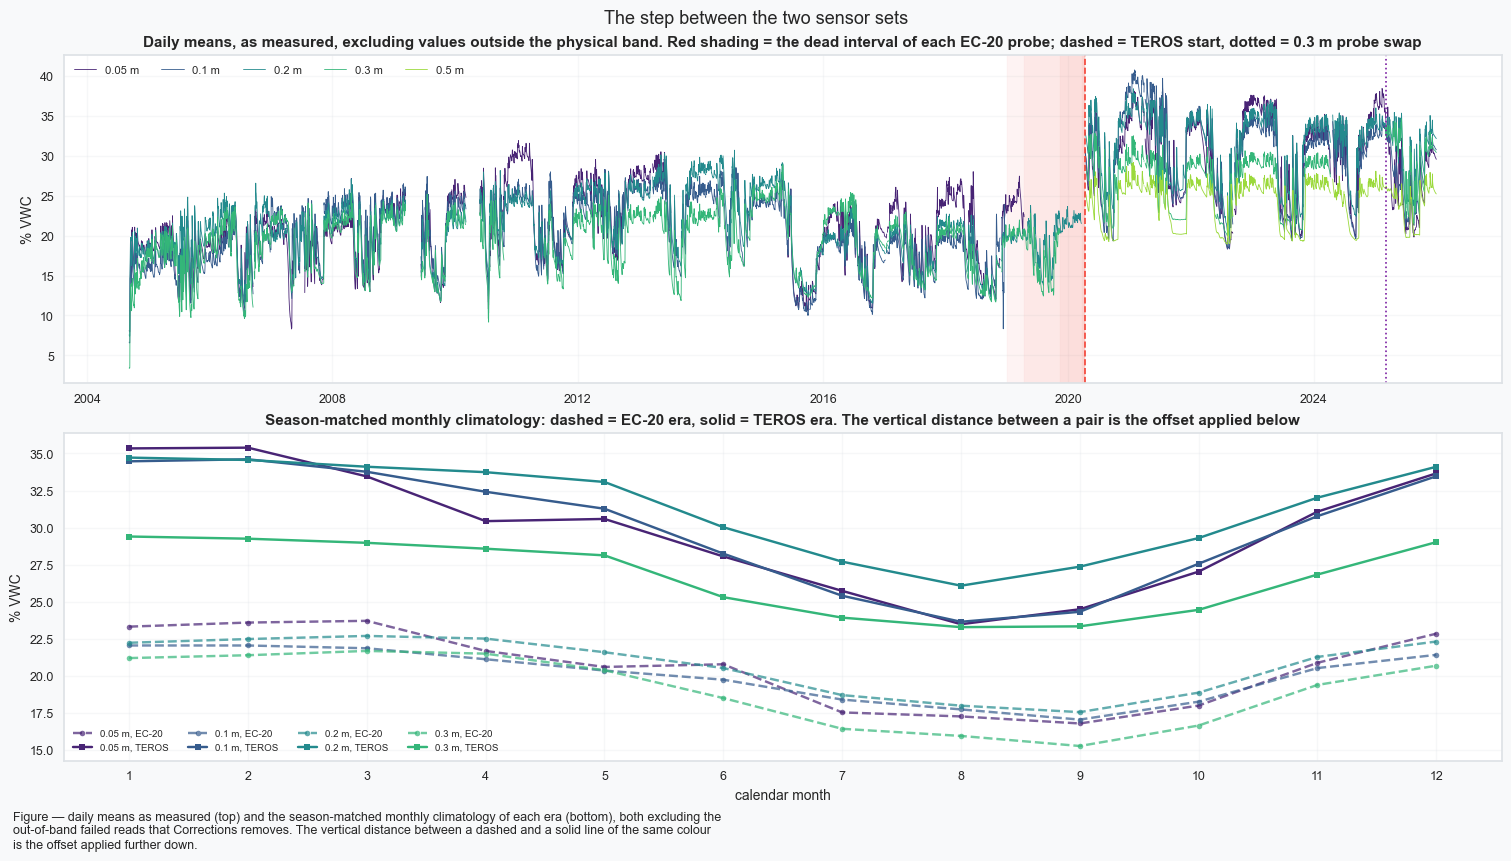

In [24]:
fig, axs = plt.subplots(nrows=2, figsize=(15, 8.5), dpi=100, layout='constrained')
fig.suptitle('The step between the two sensor sets', fontsize=13)

_colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(DEPTHS)))
for _c, d in zip(_colors, DEPTHS):
    # Band-masked, like STEPTAB and the climatology below. Plotted raw, the 0.1 m failed reads
    # near -29 % VWC stretch this axis across a range no soil moisture occupies and squash every
    # real series into the top third of the panel. They are removed for good in Corrections.
    _s = swc[field(d)]
    _daily = _s.where(_s.between(*SWC_PLAUSIBLE_PCT)).resample('1D').mean()
    axs[0].plot(_daily.index, _daily.values, lw=0.6, color=_c, label=f'{d} m')
_swap = pd.Timestamp(SENSOR_SWAP)
for d in MST_DEPTHS:
    axs[0].axvspan(mst[field(d)].last_valid_index(), diive_[field(d)].first_valid_index(),
                   color='#F44336', alpha=.06)
axs[0].axvline(diive_[field(DEPTHS[0])].first_valid_index(), color='#F44336', ls='--', lw=1.2)
axs[0].axvline(_swap, color='#7B1FA2', ls=':', lw=1.2)
axs[0].set_ylabel('% VWC')
axs[0].set_title('Daily means, as measured, excluding values outside the physical band. Red '
                 'shading = the dead interval of each EC-20 probe; dashed = TEROS start, '
                 'dotted = 0.3 m probe swap', fontsize=11)
axs[0].legend(fontsize=8, ncol=5)

for _c, d in zip(_colors, STEP_DEPTHS):
    e1, e2 = era_series(d, FLAG_EC20_MST), era_series(d, FLAG_TEROS_DIIVE)
    if e1.empty:
        continue
    axs[1].plot(range(1, 13), e1.groupby(e1.index.month).mean().reindex(range(1, 13)),
                marker='o', ms=4, ls='--', color=_c, alpha=.7, label=f'{d} m, EC-20')
    axs[1].plot(range(1, 13), e2.groupby(e2.index.month).mean().reindex(range(1, 13)),
                marker='s', ms=4, ls='-', color=_c, label=f'{d} m, TEROS')
axs[1].set_xticks(range(1, 13))
axs[1].set_xlabel('calendar month')
axs[1].set_ylabel('% VWC')
axs[1].set_title('Season-matched monthly climatology: dashed = EC-20 era, solid = TEROS era. '
                 'The vertical distance between a pair is the offset applied below', fontsize=11)
axs[1].legend(fontsize=7, ncol=4)
figcap(fig, 'daily means as measured (top) and the season-matched monthly climatology of each era '
            '(bottom), both excluding the out-of-band failed reads that Corrections removes. The '
            'vertical distance between a dashed and a solid line of the same colour is the offset '
            'applied further down.')

***

## ✴️ Corrections

Two defects are fixed here, and both come from one place: **the EC-20 era was screened once, by the
old MeteoScreeningTool, and never re-screened by diive.**

**1. Failed sensor reads stored as numbers.** The CR1000 firmware predates SDI-12 NaN support, so a
failed read produces not a gap but that sensor's calibration polynomial at zero response — a fixed
negative value per sensor. One mst depth carries a run of them at the very end of its life.
`notna()` does not mean "measured", and the missing-value flag cannot catch these; absolute limits
can. They are **removed, not clipped**: clipping to the physical minimum would turn a failed read
into a fabricated 0 % VWC, a worse lie than a gap because it looks like bone-dry soil.

A removed record becomes flag `0`, not a new "removed here" code, and that is deliberate — the
vocabulary says what *measured* a value, and a calibration polynomial at zero response never
measured anything.

**2. The FF-A / FF-B duplicate**, already handled at download and verified above.

Everything else leaves the measured values alone.

In [25]:
print("Removing values outside the physical band "
      f"{SWC_PLAUSIBLE_PCT[0]}..{SWC_PLAUSIBLE_PCT[1]} % VWC (removed, never clipped):\n")

_rows = []
for d in DEPTHS:
    f, fc = field(d), flagcol(d)
    bad = swc[f].notna() & ~swc[f].between(*SWC_PLAUSIBLE_PCT)
    n = int(bad.sum())
    if n:
        for _code in sorted(swc.loc[bad, fc].unique()):
            _m = bad & (swc[fc] == _code)
            _rows.append({'depth_m': float(d), 'flag': int(_code), 'era': ERA_NAMES[int(_code)],
                          'n_removed': int(_m.sum()), 'min': round(float(swc.loc[_m, f].min()), 3),
                          'max': round(float(swc.loc[_m, f].max()), 3),
                          'first': swc.index[_m][0], 'last': swc.index[_m][-1]})
        swc.loc[bad, f] = np.nan
        swc.loc[bad, fc] = FLAG_NOT_MEASURED
    print(f"  {f:<18} removed {n:>5,}")

REMOVED = pd.DataFrame(_rows)
if len(REMOVED):
    tabcap('every record removed for lying outside the physical band, by depth and era. All are '
           'failed SDI-12 reads frozen at a fixed negative constant in the mst era - never a '
           'measurement, so they become flag 0 rather than a "removed here" code.')
    display(REMOVED.set_index(['depth_m', 'flag']))
else:
    print("Nothing outside the band. Re-read this section before deleting it: the 0.1 m mst\n"
          "record is documented to carry ~690 negative records at the end of 2018.")

# The flag was demoted with the value, so the two still tell one story.
for d in DEPTHS:
    assert (swc[field(d)].notna() == swc[flagcol(d)].isin(MEASURED_FLAGS)).all(), \
        f"{field(d)}: flag and value disagree after the removal"
    assert swc[field(d)].dropna().between(*SWC_PLAUSIBLE_PCT).all(), \
        f"{field(d)}: a value survived outside the band"
print("\nFlag and value still agree at every depth, and nothing outside the band survives.")

Removing values outside the physical band 0.0..60.0 % VWC (removed, never clipped):

  SWC_FF1_0.05_1     removed     0
  SWC_FF1_0.1_1      removed   690
  SWC_FF1_0.2_1      removed     0
  SWC_FF1_0.3_1      removed     0
  SWC_FF1_0.5_1      removed     0
Table — every record removed for lying outside the physical band, by depth and era. All are failed
SDI-12 reads frozen at a fixed negative constant in the mst era - never a measurement, so they
become flag 0 rather than a "removed here" code.



,,era,n_removed,min,max,first,last
depth_m,flag,,,,,,
0.1,1,EC-20 / mst,690,-28.743,-4.99,2018-12-17 15:15:00,2018-12-31 23:45:00



Flag and value still agree at every depth, and nothing outside the band survives.


### What is *not* corrected, and why

The corrections notebooks `01`-`05` apply are each omitted by decision, not oversight. The 2012 rows
are the uncomfortable ones and are argued rather than waved away — starting with what the profile's
coverage actually did through those windows.

In [26]:
# The three 2012 site faults, on the corrected time axis of notebooks 01-05. Reported here, not
# applied: what the profile's coverage did through them is a fact this notebook can establish.
WINDOWS_2012 = [('2012-08-16', '2012-08-18', 'logger clock error, +15.5 h shift of one block'),
                ('2012-07-25', '2012-08-15', 'power supply failure'),
                ('2012-10-25', '2012-11-15', 'storm damage')]

for _a, _b, _why in WINDOWS_2012:
    _w = swc.loc[_a:_b]
    _cov = {d: f"{100 * _w[field(d)].notna().mean():.0f}%" for d in MST_DEPTHS}
    print(f"{_a} -> {_b}  ({_why})")
    print(f"   FF1 coverage: {_cov}")
print()
fieldbook_near('2012-08-17', days=3)

2012-08-16 -> 2012-08-18  (logger clock error, +15.5 h shift of one block)
   FF1 coverage: {'0.05': '100%', '0.1': '100%', '0.2': '100%', '0.3': '100%'}
2012-07-25 -> 2012-08-15  (power supply failure)
   FF1 coverage: {'0.05': '100%', '0.1': '100%', '0.2': '100%', '0.3': '100%'}
2012-10-25 -> 2012-11-15  (storm damage)
   FF1 coverage: {'0.05': '100%', '0.1': '100%', '0.2': '100%', '0.3': '100%'}

   2012-08-15 [FBA           ] 15.08.2012 (person 01) check for eddy data and the wireless connection dismounted the cable from tree F thermocoupple –> rearanged all the cables to the hut site. some of the poles were broken or loosen. installed the wireless device power disconnect at the forest floor station rearranged the cables from the soil water potetial sensors at the forest floor site and connect cables for the sdi12 serial connection via te
   2012-08-17 [FBA           ] 17.08.2012 (person 01, person 69, person 18, person 46) Ethernet Protect of phenocam replaced. Tried to adjust cam

| correction in `01`-`05` | applied here? | why |
|---|---|---|
| +15.5 h clock shift, Aug 2012 | **no — and this is an open question, not a clean no** | The shift is a *tower logger* fault. The FF1 profile is on the separate FF datalogger, and the fieldbook's own 2012 soil entry names the "FF Logger". But the entry that documents the clock error names only "the logger", and the profile's coverage through the window (above) neither confirms nor refutes a shared fault. Worse, the fault is **undetectable in this variable**: soil moisture has no diurnal cycle to align against, and there is no independent soil sensor anywhere. So sub-daily timestamps in Aug 2012 carry the same suspicion as the tower variables, and this is listed in the closing notes rather than silently resolved either way. |
| removal of the 2012 damaged periods | **no** | Same reasoning as notebook `08`: removing sound data because a *different* system failed would be superstition. Where the FF logger did share the fault, the coverage above already shows a gap; where it did not, the data are real. |
| nighttime zero-offset | **no** | Meaningless: soil moisture has no night. |
| unit harmonisation | **no** | Both data versions are tagged `%` with `offset = 0`, and the stored magnitudes agree with the tag at every depth. The differing `gain` tags are a property of each era's raw source, not of the stored values — checked above, and nothing is rescaled. |
| rescaling the pre-2020 era **in place** | **no** | It is shifted, but into the `_HOMOGENIZED` columns; the measured columns keep the measured values. |

: Each correction applied by notebooks `01`-`05`, and why it is or is not applied here. {#tbl-corrections}

::: {.callout-note title="The trap from notebook 03"}
Notebook `03` had a correction that wrote values into gaps and thereby relabelled 7,543 modelled
records as measured. The equivalent trap here would be an offset written onto a record that has no
measurement. It is closed structurally rather than by care: the offsets are added to
`SWC_FF1_<d>_1`, which is `NaN` in every gap, so `NaN + offset` stays `NaN` — and the export then
asserts that each `_HOMOGENIZED` column is non-null in exactly the records where its measured column
is. **The only correction in this notebook that touches the measured values removes them.**
:::

***

## ⚖️ Homogenising the pre-2020 era

::: {.callout-important title="This is the weakest thing in this notebook. Read it before using the columns."}
Notebook `08` homogenised one precipitation era onto another using an **independent gauge that
measured straight through the break**. That anchor is what made its factors defensible.

**Here there is no anchor at all.** The eras do not overlap by a single half-hour, no weather service
measures this plot's soil, and the other four depths all swap sensors on the same day, so they
cannot referee each other either. The offsets come from **climatology alone**: mean of era 2 in month
*m*, minus mean of era 1 in month *m*.

That carries three assumptions, none testable with the data in this product:

1. **That the two periods had the same monthly soil-moisture climate.** Any genuine climatic
   difference between 2004-2019 and 2020-2025 is absorbed into the offsets and re-issued as an
   instrument correction.
2. **That era 1 is internally homogeneous.** The GIN inventory flags three of the four EC-20s as
   `DEFECTIVE`, and a probe that dies in 2019 was probably drifting for years. A per-month offset
   cannot represent a drift.
3. **That the TEROS level is the right reference.** It is chosen for being modern, still running and
   diive-screened — not because anything establishes it as correct.

**Therefore:** the `_HOMOGENIZED` columns are for **continuity and trend work that has to cross
2020**. They are **not** an estimate of absolute soil water content before 2020, and not a
calibration. If your analysis lives inside one era, use the measured columns and ignore these.
:::

**At 0.3 m the third era is weaker still.** The replacement probe has only Mar-Dec 2025 — ten
calendar months of a single year — against a multi-year era-2 climatology, and it sits 40 cm down the
slope in different soil. Its own screening notebook measures the level step at about +3 % VWC against
the neighbouring depths and deliberately does not correct it. Here it *is* corrected, because the
point of the homogenised column is a continuous series. That makes 0.3 m the least trustworthy of the
four, and January and February 2025 have no season-matched estimate at all.

In [27]:
# A depth gets a homogenised column only if it carries MORE THAN ONE sensor era, re-derived from
# the flags after the corrections above. 0.5 m has a single era, so it gets none: exporting a copy
# of its measured column would invite someone to difference the two, get zero, and conclude the
# record is homogeneous - true for 0.5 m, false for every other depth.
HOMOG_DEPTHS = multi_era_depths()
SINGLE_ERA_DEPTHS = [d for d in DEPTHS if d not in HOMOG_DEPTHS]
print(f"homogenised columns for: {HOMOG_DEPTHS} m")
print(f"no homogenised column for: {SINGLE_ERA_DEPTHS} m (a single sensor era - nothing to shift)\n")

OFFSETS = {}     # {depth: {flag_code: (table, fallback)}}
for d in HOMOG_DEPTHS:
    ref = era_series(d, FLAG_TEROS_DIIVE)          # the reference level
    OFFSETS[d] = {}
    for _code in (FLAG_EC20_MST, FLAG_TEROS_REPLACEMENT):
        src = era_series(d, _code)
        if src.empty:
            continue
        OFFSETS[d][_code] = derive_monthly_offsets(
            src, ref, f'{field(d)}  era {_code} -> era {FLAG_TEROS_DIIVE}')

_tab = pd.DataFrame({f'{d} m  era {c}': OFFSETS[d][c][0]['offset']
                     for d in HOMOG_DEPTHS for c in OFFSETS[d]})
_tab.index.name = 'month'
print()
tabcap('the additive offset applied to each non-reference era, per calendar month. Era 1 is lifted '
       'onto the TEROS level; era 3, which reads high, is pushed down onto it.')
display(_tab.round(2))

homogenised columns for: ['0.05', '0.1', '0.2', '0.3'] m
no homogenised column for: ['0.5'] m (a single sensor era - nothing to shift)

  SWC_FF1_0.05_1  era 1 -> era 2               12/12 months fitted   offsets +6.21 .. +12.01   mean +9.30 % VWC
  SWC_FF1_0.1_1  era 1 -> era 2                12/12 months fitted   offsets +5.90 .. +12.55   mean +9.94 % VWC
  SWC_FF1_0.2_1  era 1 -> era 2                12/12 months fitted   offsets +8.08 .. +12.48   mean +10.66 % VWC
  SWC_FF1_0.3_1  era 1 -> era 2                12/12 months fitted   offsets +6.80 .. +8.32   mean +7.61 % VWC
  SWC_FF1_0.3_1  era 3 -> era 2                10/12 months fitted   offsets -4.26 .. -1.13   mean -3.11 % VWC

Table — the additive offset applied to each non-reference era, per calendar month. Era 1 is lifted
onto the TEROS level; era 3, which reads high, is pushed down onto it.



,0.05 m era 1,0.1 m era 1,0.2 m era 1,0.3 m era 1,0.3 m era 3
month,,,,,
1,12.01,12.41,12.48,8.19,-3.11
2,11.78,12.55,12.07,7.85,-3.11
3,9.73,11.89,11.40,7.28,-3.96
4,8.75,11.28,11.21,7.07,-3.96
5,9.97,10.90,11.47,7.74,-3.66
6,7.27,8.49,9.49,6.80,-4.26
7,8.19,7.00,8.99,7.49,-1.13
8,6.21,5.90,8.08,7.33,-1.48
9,7.70,7.26,9.80,8.06,-3.08


### The reference period is not the same at every depth

`derive_monthly_offsets` fits every era onto the **TEROS `FF1` era (flag `2`)**, and that era does
not cover the same years at every depth: at 0.05 / 0.1 / 0.2 m it runs from April 2020 to the end of
2025, but at 0.3 m it **ends at the April 2024 probe failure**, because everything from 2025-03-04
is flag `3`.

That follows from keeping the two TEROS probes apart, which is worth more than a common baseline —
folding the replacement into the level it is measured against would hide the 2025 step flag `3`
exists to expose. But it means the four `_HOMOGENIZED` columns are **not on one reference period**,
so a difference taken *between depths* across the break carries whatever 2024-2025 anomaly separates
the two baselines.

The cell below measures that, refitting the three full-length depths against a reference truncated to
0.3 m's window. Only the years sampled change between the two fits — the instrument pair is held
fixed — so whatever moves is the years alone, which is also this notebook's only handle on the
question left open in *The step is not the same in every month*. 0.3 m defines the truncation and
must therefore come back at exactly zero, which is what makes the other three numbers readable.
Nothing here is applied.

In [28]:
# The reference period actually used at each depth - read off the flags, not declared.
_rows = []
for d in HOMOG_DEPTHS:
    _ref = era_series(d, FLAG_TEROS_DIIVE)
    _rows.append({'depth_m': float(d), 'ref_first': _ref.index[0], 'ref_last': _ref.index[-1],
                  'ref_n': len(_ref),
                  'ref_years': round((_ref.index[-1] - _ref.index[0]).days / 365.25, 2)})
REFTAB = pd.DataFrame(_rows).set_index('depth_m')
tabcap('the reference era actually used at each depth. 0.3 m ends at the 2024 probe failure, so it '
       'is fitted against a shorter baseline than the other three.')
display(REFTAB)

REF_END_SHARED = REFTAB['ref_last'].min()          # the shortest reference window, i.e. 0.3 m's
print(f"one reference period at every depth: {REFTAB['ref_last'].nunique() == 1}")
print(f"shortest reference window ends {REF_END_SHARED} - every depth is refitted against that.\n")

# Refit against a reference truncated to the shortest window and compare. Quiet, because the table
# below is the result; NOTHING here is applied to the product.
_rows = []
for d in HOMOG_DEPTHS:
    _src = era_series(d, FLAG_EC20_MST)
    _ref_full = era_series(d, FLAG_TEROS_DIIVE)
    _t_full, _mean_full = derive_monthly_offsets(_src, _ref_full, d, verbose=False)
    _t_trunc, _mean_trunc = derive_monthly_offsets(_src, _ref_full.loc[:REF_END_SHARED], d,
                                                   verbose=False)
    _rows.append({'depth_m': float(d), 'mean_offset_full': _mean_full,
                  'mean_offset_truncated': _mean_trunc,
                  'mean_shift': _mean_trunc - _mean_full,
                  'max_abs_monthly_shift': float((_t_trunc['offset'] - _t_full['offset']).abs().max())})
BASELINE = pd.DataFrame(_rows).set_index('depth_m').round(3)
tabcap('how far each depth\'s offsets move when the reference is truncated to 0.3 m\'s window. '
       'This is the size of the cross-depth baseline difference the _HOMOGENIZED columns carry, '
       'and a lower bound on how much of a monthly offset is the years sampled rather than the '
       'instruments compared.')
display(BASELINE)

# The control: for the depth that DEFINES the shortest window the truncated reference is the full
# one, so its shift must be exactly zero. Found from the table rather than assumed to be 0.3 m - if
# a re-screening ever makes another depth the shortest, the control moves with it.
_ctrl = REFTAB.index[REFTAB['ref_last'] == REF_END_SHARED]
assert len(_ctrl) >= 1, "no depth defines the shortest reference window - REFTAB is inconsistent"
for _d in _ctrl:
    assert abs(float(BASELINE.loc[_d, 'mean_shift'])) < 1e-9, (
        f"{_d} m moved when its own reference was 'truncated' to its own end - the truncation is "
        f"not doing what this section says it does")

print(f"control: {list(_ctrl)} m define the shortest window and shift by exactly 0, as they must.")
print(f"Truncating the reference to {REF_END_SHARED.date()} moves a depth's mean offset by at most "
      f"{BASELINE['mean_shift'].abs().max():.2f} % VWC,\nand a single calendar month by at most "
      f"{BASELINE['max_abs_monthly_shift'].max():.2f} % VWC. Reported, not corrected: giving 0.3 m "
      f"the same\nwindow as the others means folding its 2025 replacement probe into the level it "
      f"is measured against.")

Table — the reference era actually used at each depth. 0.3 m ends at the 2024 probe failure, so it
is fitted against a shorter baseline than the other three.



,ref_first,ref_last,ref_n,ref_years
depth_m,,,,
0.05,2020-04-10 14:45:00,2025-12-31 23:45:00,94462,5.72
0.10,2020-04-10 14:45:00,2025-12-31 23:45:00,98539,5.72
0.20,2020-04-10 14:45:00,2025-12-31 23:45:00,98552,5.72
0.30,2020-04-10 14:45:00,2024-04-09 16:45:00,69152,4.00


one reference period at every depth: False
shortest reference window ends 2024-04-09 16:45:00 - every depth is refitted against that.

Table — how far each depth's offsets move when the reference is truncated to 0.3 m's window. This is
the size of the cross-depth baseline difference the _HOMOGENIZED columns carry, and a lower bound on
how much of a monthly offset is the years sampled rather than the instruments compared.



,mean_offset_full,mean_offset_truncated,mean_shift,max_abs_monthly_shift
depth_m,,,,
0.05,9.302,9.469,0.167,1.190
0.10,9.938,10.276,0.337,1.231
0.20,10.660,10.586,-0.074,0.869
0.30,7.614,7.614,0.000,0.000


control: [0.3] m define the shortest window and shift by exactly 0, as they must.
Truncating the reference to 2024-04-09 moves a depth's mean offset by at most 0.34 % VWC,
and a single calendar month by at most 1.23 % VWC. Reported, not corrected: giving 0.3 m the same
window as the others means folding its 2025 replacement probe into the level it is measured against.


In [29]:
# Applied to the measured column. A gap is NaN, and NaN + offset is NaN, so the offsets cannot
# turn a gap into a value - the structural version of notebook 03's lesson.
_months = full_index.month
for d in DEPTHS:
    if d not in HOMOG_DEPTHS:
        continue
    off = np.zeros(len(full_index))
    for _code, (_t, _) in OFFSETS[d].items():
        _mask = (swc[flagcol(d)] == _code).to_numpy()
        off = np.where(_mask, _t['offset'].reindex(_months).to_numpy(), off)
    swc[homogcol(d)] = swc[field(d)] + off
    _shifted = int(((swc[flagcol(d)].isin([FLAG_EC20_MST, FLAG_TEROS_REPLACEMENT]))
                    & swc[field(d)].notna()).sum())
    print(f"  {homogcol(d):<34} shifted {_shifted:>7,} records, "
          f"left {int((swc[flagcol(d)] == FLAG_TEROS_DIIVE).sum()):>7,} unchanged")

# Invariants. Each one is a way the homogenisation could quietly corrupt the product.
for d in HOMOG_DEPTHS:
    h, v, fl = swc[homogcol(d)], swc[field(d)], swc[flagcol(d)]
    assert h.isna().equals(v.isna()), f"{homogcol(d)}: changed which records are missing"
    _ref = fl == FLAG_TEROS_DIIVE
    assert ((h[_ref] - v[_ref]).abs() < 1e-9).all(), \
        f"{homogcol(d)}: the TEROS era was modified, but it IS the reference level"
    assert (h.dropna() >= 0).all() and (h.dropna() <= 100).all(), \
        f"{homogcol(d)}: a homogenised value left the physical range"
    _n_over = int((h.dropna() > SWC_PLAUSIBLE_PCT[1]).sum())
    if _n_over:
        print(f"  (!) {homogcol(d)}: {_n_over:,} homogenised values exceed "
              f"{SWC_PLAUSIBLE_PCT[1]} % VWC - a shifted estimate, not a measurement, so it is "
              f"kept and flagged here rather than clipped")
print("\nGaps untouched, the reference era untouched, every shifted value inside the physical range.")

  SWC_FF1_0.05_1_HOMOGENIZED         shifted 207,596 records, left  94,462 unchanged
  SWC_FF1_0.1_1_HOMOGENIZED          shifted 238,767 records, left  98,539 unchanged
  SWC_FF1_0.2_1_HOMOGENIZED          shifted 260,311 records, left  98,552 unchanged
  SWC_FF1_0.3_1_HOMOGENIZED          shifted 253,938 records, left  69,152 unchanged

Gaps untouched, the reference era untouched, every shifted value inside the physical range.


### Does it land where it should?

By construction the fitted months land exactly on the reference level, so agreeing with them proves
only that the arithmetic is right — worth proving, and all it proves. The honest check is the second
table: annual means before and after, and whether the residual step across 2020 has gone.

In [30]:
_rows = []
for d in HOMOG_DEPTHS:
    for _code in OFFSETS[d]:
        _src_h = swc[homogcol(d)].where(swc[flagcol(d)] == _code).dropna()
        _ref = era_series(d, FLAG_TEROS_DIIVE)
        _t = OFFSETS[d][_code][0]
        _fitted = _t.index[_t['fitted']]
        _a = _src_h.groupby(_src_h.index.month).mean().reindex(_fitted)
        _b = _ref.groupby(_ref.index.month).mean().reindex(_fitted)
        _rows.append({'depth_m': float(d), 'flag': _code, 'months_fitted': len(_fitted),
                      'max_abs_residual': float((_a - _b).abs().max())})
_landing = pd.DataFrame(_rows).set_index(['depth_m', 'flag'])
tabcap('residual between each homogenised era and the reference level, in the months its offsets '
       'were fitted on. Zero by construction - this checks the arithmetic and nothing else.')
display(_landing.round(9))
assert (_landing['max_abs_residual'] < 1e-6).all(), \
    "a homogenised era does not land on the reference level in its own fitted months"

_before = {}
for d in HOMOG_DEPTHS:
    _e1 = swc[field(d)].where(swc[flagcol(d)] == FLAG_EC20_MST).dropna()
    _e1h = swc[homogcol(d)].where(swc[flagcol(d)] == FLAG_EC20_MST).dropna()
    _before[f'{d} m'] = {'era1 measured': float(_e1.mean()),
                         'era1 homogenised': float(_e1h.mean()),
                         'era2 (reference)': float(era_series(d, FLAG_TEROS_DIIVE).mean())}
_land = pd.DataFrame(_before).T
_land['residual step'] = _land['era2 (reference)'] - _land['era1 homogenised']
tabcap('era means before and after homogenisation. The season-matched step is gone; what remains '
       'is the difference in which months each era actually sampled, which is real.')
display(_land.round(3))

# Loose on purpose. The residual is NOT expected to be zero: the two eras sample different months in
# different proportions - era 2 begins in mid-April 2020 and so under-weights one winter - and that
# difference is real, not an error in the offsets. The band only has to catch an offset applied with
# the wrong sign, to the wrong era, or in the wrong unit.
assert _land['residual step'].abs().max() < 2.0, \
    "the homogenised pre-2020 era does not sit anywhere near the TEROS level"

Table — residual between each homogenised era and the reference level, in the months its offsets
were fitted on. Zero by construction - this checks the arithmetic and nothing else.



months_fitted  max_abs_residual
depth_m flag                                 
0.05    1                12               0.0
0.10    1                12               0.0
0.20    1                12               0.0
0.30    1                12               0.0
        3                10               0.0

Table — era means before and after homogenisation. The season-matched step is gone; what remains is
the difference in which months each era actually sampled, which is real.



,era1 measured,era1 homogenised,era2 (reference),residual step
0.05 m,20.575,29.911,29.877,-0.034
0.1 m,19.995,29.861,29.773,-0.088
0.2 m,20.693,31.344,31.232,-0.112
0.3 m,18.920,26.549,26.714,0.165


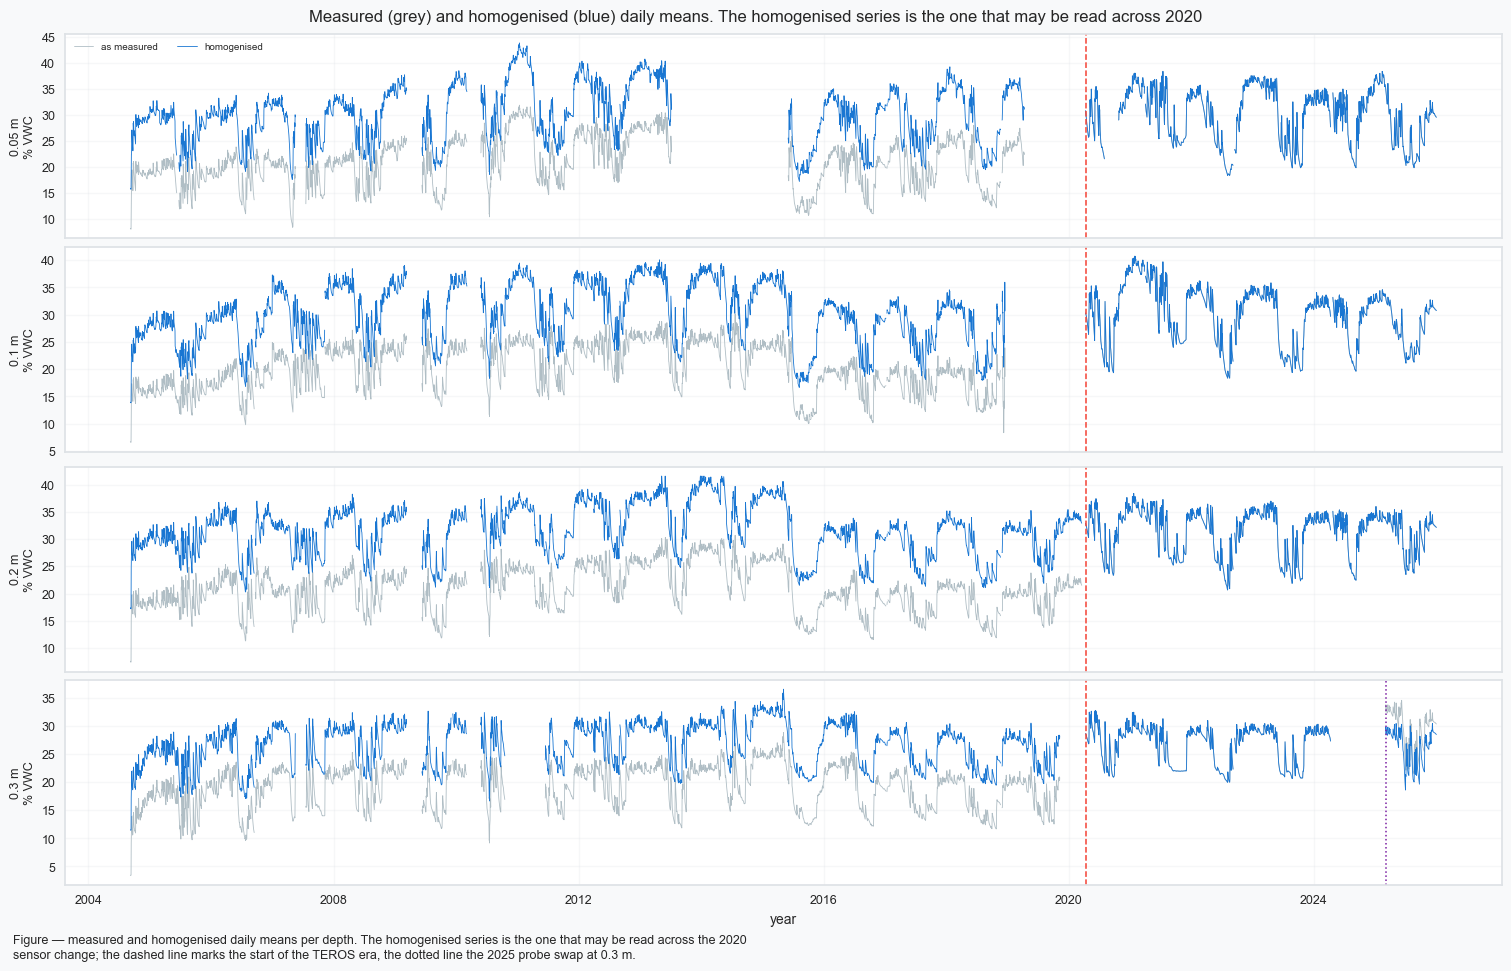

In [31]:
fig, axs = plt.subplots(nrows=len(HOMOG_DEPTHS), figsize=(15, 2.4 * len(HOMOG_DEPTHS)),
                        dpi=100, layout='constrained', sharex=True)
fig.suptitle('Measured (grey) and homogenised (blue) daily means. The homogenised series is the '
             'one that may be read across 2020', fontsize=12)
for _i, (ax, d) in enumerate(zip(np.atleast_1d(axs), HOMOG_DEPTHS)):
    _m = swc[field(d)].resample('1D').mean()
    _h = swc[homogcol(d)].resample('1D').mean()
    ax.plot(_m.index, _m.values, lw=0.6, color='#B0BEC5', label='as measured')
    ax.plot(_h.index, _h.values, lw=0.6, color='#1976D2', label='homogenised')
    ax.axvline(diive_[field(d)].first_valid_index(), color='#F44336', ls='--', lw=1.1)
    if d == SWAP_DEPTH:
        ax.axvline(pd.Timestamp(SENSOR_SWAP), color='#7B1FA2', ls=':', lw=1.1)
    ax.set_ylabel(f'{d} m\n% VWC', fontsize=9)
    if _i == 0:   # the panels share one vocabulary; four identical legends is noise
        ax.legend(fontsize=7, loc='upper left', ncol=2)
np.atleast_1d(axs)[-1].set_xlabel('year')
figcap(fig, 'measured and homogenised daily means per depth. The homogenised series is the one '
            'that may be read across the 2020 sensor change; the dashed line marks the start of '
            'the TEROS era, the dotted line the 2025 probe swap at 0.3 m.')

***

## 🚫 What is not filled, and why

**Nothing in this product is gap-filled**, and unlike notebook `08` — where the decision was made
against a measured alternative — here there is no alternative to decide against.

- **No external reference exists.** MeteoSwiss measures no soil moisture at this plot, at Lägern or
  at Ehrendingen, and there is no NABEL soil profile. The nearest thing is the other four depths of
  this same profile, which is what the `20_SCREENING/SWC` notebooks use as a cross-check — and which
  is useless as a *fill* source, because the depths swap sensors on the same day and share every
  power and logger fault.
- **The largest gaps are the inter-era gaps**, and filling them would be the worst thing this
  notebook could do. Interpolating a state variable across 363 days of a dead probe produces a
  smooth, plausible, entirely fabricated year — the failure mode soil moisture is most vulnerable
  to, because a wrong SWC series looks exactly like a right one.
- **Some era-1 gaps are explained, and the explanation makes filling them worse.** Both whole-station
  gaps longer than 60 days were a dead logger. A dead logger means no soil was measured, not that the soil
  did nothing.

The inventory below is what a downstream user needs in order to choose which periods to use.

In [32]:
_rows = []
for d in DEPTHS:
    s = swc[field(d)]
    _present = s.notna()
    # Runs of consecutive missing records, ignoring the period before the depth's own record starts.
    _first = s.first_valid_index()
    _m = ~_present.loc[_first:]
    _grp = (_m != _m.shift()).cumsum()[_m]
    _runs = _m.loc[_m].groupby(_grp).size() * 0.5 / 24  # records -> days
    _rows.append({'depth_m': float(d), 'record_starts': _first,
                  'n_measured': int(_present.sum()),
                  'coverage_since_start_%': round(100 * float(_present.loc[_first:].mean()), 2),
                  'n_gaps': int(len(_runs)),
                  'gaps_over_30d': int((_runs > 30).sum()),
                  'longest_gap_d': round(float(_runs.max()) if len(_runs) else 0.0, 1)})
GAPTAB = pd.DataFrame(_rows).set_index('depth_m')
tabcap('coverage and gap structure of each depth since its own record begins. The longest gap at '
       'four of the five depths is an inter-era gap, i.e. a dead probe rather than an outage.')
display(GAPTAB)

def missing_blocks(mask: pd.Series):
    """Contiguous runs of True in a boolean series, as (first, last, n_records)."""
    grp = (mask != mask.shift()).cumsum()
    return [(g.index[0], g.index[-1], len(g)) for _, g in mask[mask].groupby(grp[mask])]


print("The five longest gaps per depth, with the era on each side:\n")
for d in DEPTHS:
    s = swc[field(d)]
    _first = s.first_valid_index()
    _blocks = sorted(missing_blocks((~s.notna()).loc[_first:]), key=lambda t: -t[2])[:5]
    print(f"  {field(d)}")
    for _a, _b, _n in _blocks:
        _is_inter = (d in INTER_ERA_GAP) and (_a > mst[field(d)].last_valid_index()) and \
                    (_b < diive_[field(d)].first_valid_index())
        print(f"     {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}   {_n * 0.5 / 24:6.1f} d"
              f"{'   <- the dead interval between the two sensor sets' if _is_inter else ''}")

Table — coverage and gap structure of each depth since its own record begins. The longest gap at
four of the five depths is an inter-era gap, i.e. a dead probe rather than an outage.



,record_starts,n_measured,coverage_since_start_%,n_gaps,gaps_over_30d,longest_gap_d
depth_m,,,,,,
0.05,2004-09-07 13:45:00,302058,80.83,100,6,695.1
0.10,2004-09-07 13:45:00,337306,90.26,105,3,480.0
0.20,2004-09-07 13:45:00,358863,96.03,108,2,92.9
0.30,2004-09-07 13:45:00,323090,86.46,70,6,328.9
0.50,2020-04-10 14:45:00,98588,98.21,31,0,14.3


The five longest gaps per depth, with the era on each side:

  SWC_FF1_0.05_1
     2013-07-08 -> 2015-06-03    695.1 d
     2019-04-13 -> 2020-04-10    363.6 d   <- the dead interval between the two sensor sets
     2009-03-10 -> 2009-06-11     92.9 d
     2020-08-01 -> 2020-10-23     84.0 d
     2010-03-06 -> 2010-05-28     82.9 d
  SWC_FF1_0.1_1
     2018-12-17 -> 2020-04-10    480.0 d
     2009-03-10 -> 2009-06-11     92.9 d
     2010-03-06 -> 2010-05-28     82.9 d
     2024-04-09 -> 2024-04-23     14.3 d
     2013-03-09 -> 2013-03-22     12.6 d
  SWC_FF1_0.2_1
     2009-03-10 -> 2009-06-11     92.9 d
     2010-03-06 -> 2010-05-28     82.9 d
     2020-03-19 -> 2020-04-10     22.6 d   <- the dead interval between the two sensor sets
     2024-04-09 -> 2024-04-23     14.3 d
     2013-03-09 -> 2013-03-22     12.6 d
  SWC_FF1_0.3_1
     2024-04-09 -> 2025-03-04    328.9 d
     2010-10-18 -> 2011-06-16    240.8 d
     2019-11-09 -> 2020-04-10    153.6 d   <- the dead interval between the

### The whole-station gaps of the EC-20 era, and what caused them

**Evidence first, fieldbook second.** The cell below scans the EC-20 era blind for periods where
**all four** depths are missing at once — a whole-station failure rather than one dead probe — and
only then asks the legacy record what happened there.

Both long ones come back with an answer that matches the data to the day: a remark of 23.07.2010
added to the 31.05.2009 entry, *"No forest floor logger data recorded from doy 69 to 162"*; and a
remark added to the 17.05.2010 entry recording that a fuse had slipped out at the forest-floor
station between 6 March and 28 May 2010, leaving the logger without power. DOY 69-162 of 2009 is
converted and asserted against the gap the scan found rather than taken on faith. Both are power
failures of a battery-run station — the failure mode the rest of the legacy record leads one to
expect — and both are remarks written a year or more after the fact, so the corroboration runs from
the data to the note, not the other way round.

In [33]:
# All four old depths missing at once, inside the era where all four were alive.
_mst_first = min(mst[field(d)].first_valid_index() for d in MST_DEPTHS)
_mst_last_shared = min(mst[field(d)].last_valid_index() for d in MST_DEPTHS)
_all_missing = pd.Series(True, index=full_index)
for d in MST_DEPTHS:
    _all_missing &= swc[field(d)].isna()
_all_missing = _all_missing.loc[_mst_first:_mst_last_shared]

SHARED_GAPS = [(a, b, n * 0.5 / 24) for a, b, n in missing_blocks(_all_missing) if n * 0.5 / 24 > 60]
print(f"whole-station gaps longer than 60 days, {_mst_first.date()} -> "
      f"{_mst_last_shared.date()} (all {len(MST_DEPTHS)} old depths missing at once):\n")

_LEGACY_CAUSE = r'Waldboden|forest floor|Sicherung|fuse|Strom|power|logger|doy'
EXPLAINED, UNEXPLAINED = [], []
for _a, _b, _d in SHARED_GAPS:
    print(f"  {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}   {_d:.0f} days")
    _near = LEGACY[LEGACY['date'].between(_a - pd.Timedelta(days=30), _b + pd.Timedelta(days=30))]
    _cause = _near[_near['text'].str.contains(_LEGACY_CAUSE, case=False, na=False, regex=True)]
    if len(_cause):
        EXPLAINED.append((_a, _b, _d))
        for _, _r in _cause.iterrows():
            print(f"      legacy {_r['date']:%Y-%m-%d}: {_r['text'][:400]}")
    else:
        UNEXPLAINED.append((_a, _b, _d))
        print("      (no legacy sub-entry within +/-30 days)")

print(f"\nexplained: {len(EXPLAINED)} of {len(SHARED_GAPS)} whole-station gaps")
assert len(SHARED_GAPS) >= 2, ("the whole-station gaps this section explains are not in the data - "
                               "re-read the section before quoting it")
assert len(EXPLAINED) >= 2, ("the legacy record no longer explains any whole-station gap; either "
                             "the parse or the search pattern broke")

whole-station gaps longer than 60 days, 2004-09-07 -> 2018-12-31 (all 4 old depths missing at once):

  2009-03-10 -> 2009-06-11   93 days
      legacy 2009-02-25: 25.02.2009 (person 04) Li-8100 Automated Soil Chamber Restarted at 16:00 (MEWZ), Reset of powerground for Meteo station was necessary
      legacy 2009-05-31: 31.05.2009 (person 07) Hard-disk of EC-Computer broken down, restart: 1.06.2009 Remark (person 31 23.07.2010): No forest floor logger data recorded from doy 69 to 162.
  2010-03-06 -> 2010-05-28   83 days
      legacy 2010-02-10: 10.02.2010 (person 07 & person 11) neue Pumpen in Profileinhet fuer CO2-Profil eingebaut (lief die letzten Wochen vermutlich nicht check data); neue Referenzgasflasche angeschlossen (im Labor 237ppm mit Li-840 gemessen) Dendrometer 1 (von N.Ruehr) wieder angeschaltet (Stromversorgung war aus seit dem 20.01) neue Dendrometer (von R.Zweifel) wieder montiert an Fichte, neu eingestellt auf 50 mV, Dend
      legacy 2010-03-04: 04.03.2010 (person 07

In [34]:
# The DOY claim, converted and checked against the gap the scan found. This is the one place where
# the fieldbook makes a quantitative statement that the data can falsify, so it is not left as prose.
# Only doy ranges that are ABOUT the forest-floor logger: the legacy record uses day-of-year for
# other instruments too, and those are not claims about this station.
_doy_hits = LEGACY[
    LEGACY['text'].str.contains(r'doy\s*\d+\s*(?:to|bis|-|–)\s*\d+', case=False, na=False, regex=True)
    & LEGACY['text'].str.contains(r'forest floor|Waldboden|logger', case=False, na=False, regex=True)]
assert len(_doy_hits) > 0, "the doy remark about the forest-floor logger is not in the parsed record"

_confirmed, _unconfirmed = 0, []
for _, _r in _doy_hits.iterrows():
    _m = re.search(r'doy\s*(\d+)\s*(?:to|bis|-|–)\s*(\d+)', _r['text'], flags=re.I)
    _y = _r['date'].year
    _from = pd.Timestamp(year=_y, month=1, day=1) + pd.Timedelta(days=int(_m.group(1)) - 1)
    _to = pd.Timestamp(year=_y, month=1, day=1) + pd.Timedelta(days=int(_m.group(2)) - 1)
    _match = [(a, b, d) for a, b, d in SHARED_GAPS
              if abs((a - _from).days) <= 3 and abs((b - _to).days) <= 3]
    print(f"legacy {_r['date']:%Y-%m-%d}: doy {_m.group(1)}-{_m.group(2)} of {_y} "
          f"= {_from:%Y-%m-%d} -> {_to:%Y-%m-%d}")
    print(f"   whole-station gap found in the data: "
          f"{[(f'{a:%Y-%m-%d}', f'{b:%Y-%m-%d}', f'{d:.0f} d') for a, b, d in _match] or 'NONE'}")
    if _match:
        _confirmed += 1
    else:
        _unconfirmed.append((_r['date'].date(), _from.date(), _to.date()))

assert _confirmed > 0, ("no fieldbook claim about missing forest-floor data lines up with a gap in "
                        "the data - either the parse or the gap scan is wrong")
print(f"\n{_confirmed} fieldbook claim(s) confirmed by the data to within three days.")
if _unconfirmed:
    print(f"Claims that did NOT line up (worth reading before trusting them): {_unconfirmed}")
print(f"Whole-station gaps with no legacy explanation: "
      f"{[(f'{a:%Y-%m-%d}', f'{b:%Y-%m-%d}') for a, b, _ in UNEXPLAINED] or 'none'}")

legacy 2009-05-31: doy 69-162 of 2009 = 2009-03-10 -> 2009-06-11
   whole-station gap found in the data: [('2009-03-10', '2009-06-11', '93 d')]

1 fieldbook claim(s) confirmed by the data to within three days.
Whole-station gaps with no legacy explanation: none


***

## ➡️ Prepare dataframe for export

Columns are grouped **by depth** rather than by kind: value, homogenised twin, flag. A soil profile
is read one depth at a time, so a number's provenance is never more than two columns away from it.

In [35]:
EXPORT_COLS = []
for d in DEPTHS:
    EXPORT_COLS.append(field(d))
    if d in HOMOG_DEPTHS:
        EXPORT_COLS.append(homogcol(d))
    EXPORT_COLS.append(flagcol(d))

export_df = swc[EXPORT_COLS].copy()
for d in DEPTHS:
    export_df[flagcol(d)] = export_df[flagcol(d)].astype(int)
print(f"{len(EXPORT_COLS)} columns: {len(DEPTHS)} measured, {len(HOMOG_DEPTHS)} homogenised, "
      f"{len(DEPTHS)} flags")
tabcap('the exported frame: value, homogenised twin and source flag for each depth, grouped by '
       'depth so a value and its provenance stay adjacent.')
export_df

14 columns: 5 measured, 4 homogenised, 5 flags
Table — the exported frame: value, homogenised twin and source flag for each depth, grouped by depth
so a value and its provenance stay adjacent.



,SWC_FF1_0.05_1,SWC_FF1_0.05_1_HOMOGENIZED,FLAG_SWC_FF1_0.05_1_SOURCE,SWC_FF1_0.1_1,SWC_FF1_0.1_1_HOMOGENIZED,FLAG_SWC_FF1_0.1_1_SOURCE,SWC_FF1_0.2_1,SWC_FF1_0.2_1_HOMOGENIZED,FLAG_SWC_FF1_0.2_1_SOURCE,SWC_FF1_0.3_1,SWC_FF1_0.3_1_HOMOGENIZED,FLAG_SWC_FF1_0.3_1_SOURCE,SWC_FF1_0.5_1,FLAG_SWC_FF1_0.5_1_SOURCE
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,
2004-09-07 00:15:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 00:45:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 01:15:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 01:45:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
2004-09-07 02:15:00,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,29.538065,29.538065,2,30.736580,30.736580,2,32.139789,32.139789,2,30.388568,28.508098,3,25.212793,2
2025-12-31 22:15:00,29.528240,29.528240,2,30.735927,30.735927,2,32.138521,32.138521,2,30.382575,28.502105,3,25.209556,2
2025-12-31 22:45:00,29.530094,29.530094,2,30.733229,30.733229,2,32.133453,32.133453,2,30.378484,28.498014,3,25.209057,2


Sanity checks. The product is **not** expected to be complete, so what is checked is that the index
is sound, that every value present is physically plausible % VWC, and that at every depth the flag,
the value and the homogenised column tell one story.

In [36]:
_lo, _hi = SWC_PLAUSIBLE_PCT

print(f"Records:          {len(export_df):,}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}\n")

# Index invariants.
assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df.index.name == 'TIMESTAMP_MIDDLE', "the index is not named TIMESTAMP_MIDDLE"

_rows = []
for d in DEPTHS:
    v, fl = export_df[field(d)], export_df[flagcol(d)]
    # Flag and value tell one story.
    assert (v.notna() == fl.isin(MEASURED_FLAGS)).all(), \
        f"{field(d)}: a value without a flag, or a flag without a value"
    assert fl.isin(FLAG_SOURCE_LEGEND).all(), f"{flagcol(d)}: unknown flag code"
    assert fl.notna().all(), f"{flagcol(d)}: a record carries no flag"
    # Physical range.
    _vals = v.dropna()
    assert _vals.min() >= _lo and _vals.max() <= _hi, \
        f"{field(d)}: values outside {_lo}-{_hi} % VWC - possible unit or gain error"
    # The homogenised column exists exactly where its measured column does.
    if d in HOMOG_DEPTHS:
        assert export_df[homogcol(d)].notna().equals(v.notna()), \
            f"{homogcol(d)}: non-null in different records than {field(d)}"
    else:
        assert homogcol(d) not in export_df.columns, \
            f"{d} m has a single era and must not carry a homogenised column"
    _rows.append({'depth_m': float(d), 'measured': int(v.notna().sum()),
                  'coverage_%': round(100 * float(v.notna().mean()), 2),
                  'min': round(float(_vals.min()), 2), 'max': round(float(_vals.max()), 2),
                  'mean': round(float(_vals.mean()), 2),
                  'homogenised': d in HOMOG_DEPTHS})
tabcap('range and coverage of every exported value column. Coverage is against the full '
       '2004-2025 index, which is why 0.5 m reads low: it has no probe before 2020.')
display(pd.DataFrame(_rows).set_index('depth_m'))
print("All checks passed.\n")

_fc = pd.DataFrame({f'{d} m': export_df[flagcol(d)].value_counts() for d in DEPTHS}).fillna(0).astype(int)
_fc = _fc.sort_index()
_fc['meaning'] = [FLAG_SOURCE_LEGEND[i] for i in _fc.index]
tabcap('how many records each source flag holds at each depth.')
display(_fc)

Records:          373,728
Index:            2004-09-07 00:15:00 -> 2025-12-31 23:45:00
Duplicate index:  0
Index gaps:       0

Table — range and coverage of every exported value column. Coverage is against the full 2004-2025
index, which is why 0.5 m reads low: it has no probe before 2020.



,measured,coverage_%,min,max,mean,homogenised
depth_m,,,,,,
0.05,302058,80.82,7.70,39.71,23.48,True
0.10,337306,90.25,0.84,41.71,22.85,True
0.20,358863,96.02,7.32,39.03,23.59,True
0.30,323090,86.45,3.32,36.41,21.05,True
0.50,98588,26.38,18.88,31.75,24.12,False


All checks passed.

Table — how many records each source flag holds at each depth.



,0.05 m,0.1 m,0.2 m,0.3 m,0.5 m,meaning
0,71670,36422,14865,50638,275140,"0 = no measurement (gap, or before this depth'..."
1,207596,238767,260311,239424,0,"1 = EC-20 / M5 profile, MeteoScreeningTool scr..."
2,94462,98539,98552,69152,98588,2 = TEROS 12 FF1 profile installed 19 Mar 2020...
3,0,0,0,14514,0,"3 = TEROS 12 replacement probe, 40 cm downslop..."


### Per-year coverage, by sensor set

`n_1` / `n_2` / `n_3` count records of each sensor era. A year where two are non-zero is a year the
profile changed instrument, and its annual mean is not the mean of a measurement.

In [37]:
_rows = []
for d in DEPTHS:
    fl = export_df[flagcol(d)]
    _yr = fl.index.year
    # Vectorised per flag code: one boolean sum per code instead of a groupby-apply per code.
    _t = pd.DataFrame({f'n_{c}': (fl == c).groupby(_yr).sum() for c in MEASURED_FLAGS})
    _t['possible'] = fl.groupby(_yr).size()
    _t['coverage_%'] = (100 * _t[[f'n_{c}' for c in MEASURED_FLAGS]].sum(axis=1)
                        / _t['possible']).round(1)
    _t['mean_pct'] = export_df[field(d)].groupby(_yr).mean().round(2)
    _t['depth_m'] = float(d)
    _rows.append(_t.reset_index(names='year'))
YEARTAB = pd.concat(_rows).set_index(['depth_m', 'year'])
tabcap('records per year and sensor era, per depth. A year with two non-zero counts changed '
       'instrument mid-year, and its mean_pct mixes two sensor sets.')
display(YEARTAB)

_mixed = YEARTAB[(YEARTAB[[f'n_{c}' for c in MEASURED_FLAGS]] > 0).sum(axis=1) > 1]
print(f"years mixing two sensor sets (do not read their annual means): "
      f"{sorted(set(_mixed.index.get_level_values('year')))}")

Table — records per year and sensor era, per depth. A year with two non-zero counts changed
instrument mid-year, and its mean_pct mixes two sensor sets.



n_1    n_2  n_3  possible  coverage_%  mean_pct
depth_m year                                                   
0.05    2004   5541      0    0      5568        99.5     18.07
        2005  16894      0    0     17520        96.4     18.18
        2006  17067      0    0     17520        97.4     19.13
        2007  14366      0    0     17520        82.0     18.21
        2008  17566      0    0     17568       100.0     20.20
...             ...    ...  ...       ...         ...       ...
0.50    2021      0  17124    0     17520        97.7     24.33
        2022      0  17027    0     17520        97.2     24.23
        2023      0  17476    0     17520        99.7     23.75
        2024      0  16703    0     17568        95.1     24.68
        2025      0  17519    0     17520       100.0     24.33

[110 rows x 6 columns]

years mixing two sensor sets (do not read their annual means): [2020]


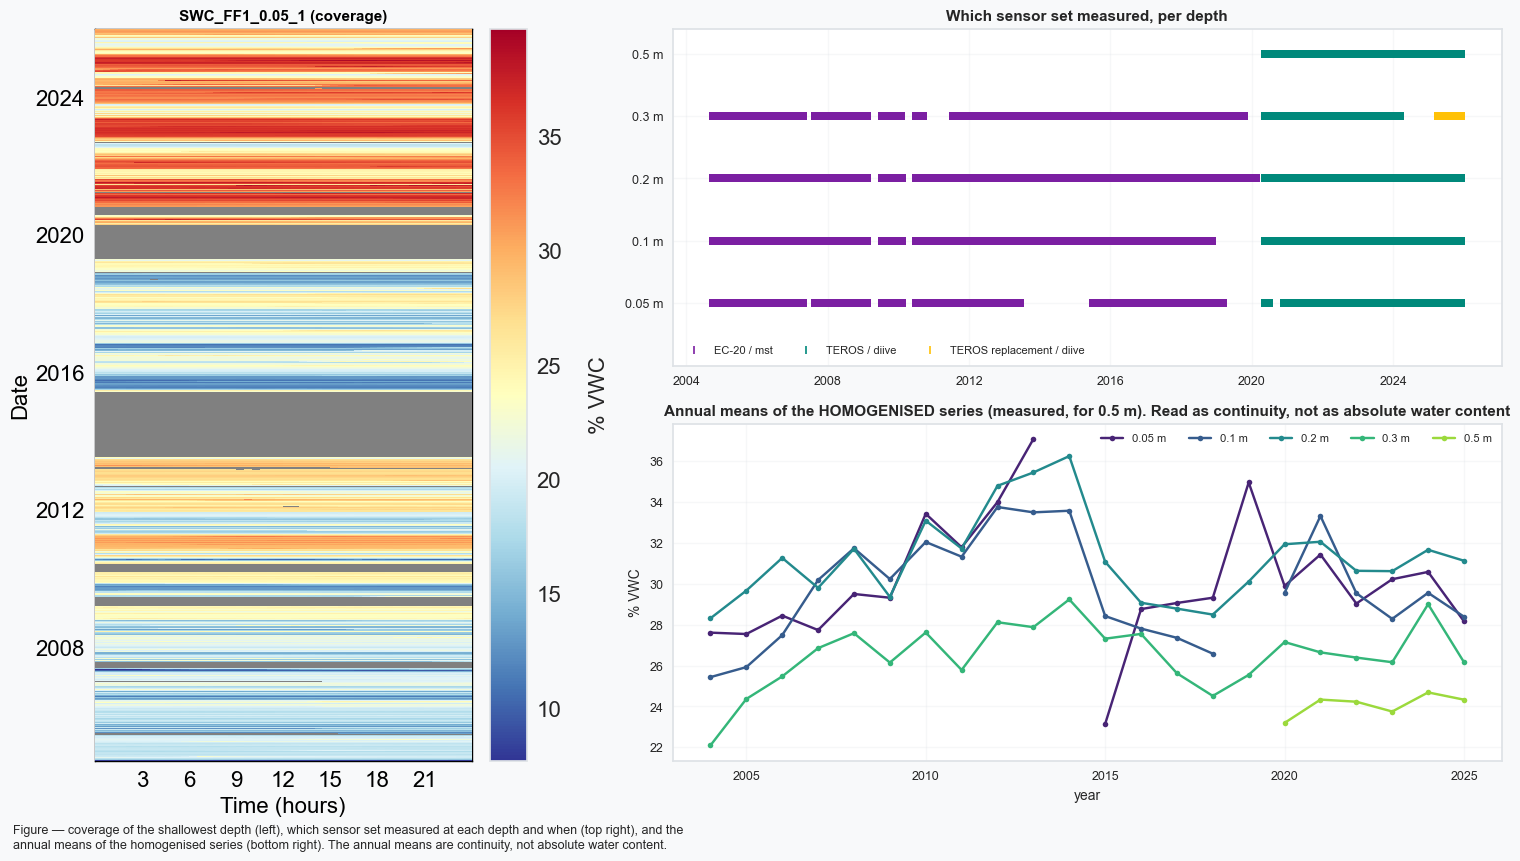

In [38]:
fig = plt.figure(figsize=(15, 8.5), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_fl = fig.add_subplot(gs[0, 1])
ax_yr = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=export_df[field(DEPTHS[0])]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel='% VWC',
    format_style=dv.plotting.FormatStyle(title=f'{field(DEPTHS[0])} (coverage)', title_fontsize=11))

for _i, d in enumerate(DEPTHS):
    _fl = export_df[flagcol(d)]
    for _code, _col in [(FLAG_EC20_MST, '#7B1FA2'), (FLAG_TEROS_DIIVE, '#00897B'),
                        (FLAG_TEROS_REPLACEMENT, '#FFC107')]:
        _ix = _fl.index[_fl == _code]
        if len(_ix):
            # mew is not decoration: "|" is drawn entirely from the marker EDGE, and
            # sns.set_theme() sets lines.markeredgewidth to 0, which renders this panel - and its
            # legend handles - completely blank. Any edge-only marker (| _ + x) needs it set.
            ax_fl.plot(_ix, np.full(len(_ix), _i), '|', color=_col, ms=6, mew=1.2,
                       label=ERA_NAMES[_code] if _i == 0 or _code == FLAG_TEROS_REPLACEMENT else None)
ax_fl.set_yticks(range(len(DEPTHS)))
ax_fl.set_yticklabels([f'{d} m' for d in DEPTHS], fontsize=9)
ax_fl.set_title('Which sensor set measured, per depth', fontsize=11)
# Room below the shallowest row for the legend, which otherwise sits on top of it.
ax_fl.set_ylim(-1.0, len(DEPTHS) - 0.6)
ax_fl.legend(fontsize=8, loc='lower left', ncol=3)

for _c, d in zip(plt.cm.viridis(np.linspace(0.1, 0.85, len(DEPTHS))), DEPTHS):
    _col = homogcol(d) if d in HOMOG_DEPTHS else field(d)
    _ann = export_df[_col].resample('YS').mean()
    ax_yr.plot(_ann.index.year, _ann.values, marker='o', ms=4, color=_c, label=f'{d} m')
ax_yr.set_xlabel('year')
ax_yr.set_ylabel('% VWC')
ax_yr.set_title('Annual means of the HOMOGENISED series (measured, for 0.5 m). Read as continuity, '
                'not as absolute water content', fontsize=11)
ax_yr.legend(fontsize=8, ncol=5)
figcap(fig, 'coverage of the shallowest depth (left), which sensor set measured at each depth and '
            'when (top right), and the annual means of the homogenised series (bottom right). The '
            'annual means are continuity, not absolute water content.')

***

## 💾 Save to file

In [39]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
# na_rep='' keeps a gap empty in the csv. Read back, a missing record must not become 0 % VWC -
# which is not "no data" but "bone dry soil", a value this soil never reaches.
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv", na_rep='')
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\09_METEO_SWC_FF1_2004-2025.parquet (0.311 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\09_METEO_SWC_FF1_2004-2025.parquet


### Verify the written file

Both files are read back and checked directly rather than trusting the in-memory frame. What must
survive the round trip is the **non-null count per column** and the **flags**; the csv trip is the
fragile one, because an empty field could come back as `0.0` and turn every gap into bone-dry soil.

In [40]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns ({len(_written.columns)}): {list(_written.columns)}")
print(f"index:   {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)\n")

assert list(_written.columns) == EXPORT_COLS, "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
for _c in EXPORT_COLS:
    assert int(_written[_c].notna().sum()) == int(export_df[_c].notna().sum()), \
        f"{_c}: non-null count changed on write - gaps may have become zeros"
for d in DEPTHS:
    assert _written[flagcol(d)].equals(export_df[flagcol(d)]), f"{flagcol(d)} changed on write"
    assert abs(float(_written[field(d)].sum()) - float(export_df[field(d)].sum())) < 1e-6, \
        f"{field(d)}: values changed on write"
    if d in HOMOG_DEPTHS:
        assert abs(float(_written[homogcol(d)].sum())
                   - float(export_df[homogcol(d)].sum())) < 1e-6, \
            f"{homogcol(d)}: values changed on write"
print("Written parquet verified.")

_csv = pd.read_csv(Path(OUTPATH) / f"{OUTNAME}.csv", index_col=0, parse_dates=True)
assert len(_csv) == len(export_df), "csv: record count changed"
assert list(_csv.columns) == EXPORT_COLS, "csv: columns changed"
for _c in EXPORT_COLS:
    assert int(_csv[_c].isna().sum()) == int(export_df[_c].isna().sum()), \
        f"csv: {_c} NaN count changed - gaps may have become zeros"
for d in DEPTHS:
    assert (_csv[flagcol(d)].astype(int) == export_df[flagcol(d)]).all(), \
        f"csv: {flagcol(d)} changed"
print("Written csv verified (gaps preserved as empty, flags unchanged).")

tabcap('measured records per year and depth, counted in the parquet file as read back from disk.')
display(pd.DataFrame({f'{d} m': _written[field(d)].groupby(_written.index.year).count()
                      for d in DEPTHS}).rename_axis('year'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\09_METEO_SWC_FF1_2004-2025.parquet (0.043 seconds).

columns (14): ['SWC_FF1_0.05_1', 'SWC_FF1_0.05_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.05_1_SOURCE', 'SWC_FF1_0.1_1', 'SWC_FF1_0.1_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.1_1_SOURCE', 'SWC_FF1_0.2_1', 'SWC_FF1_0.2_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.2_1_SOURCE', 'SWC_FF1_0.3_1', 'SWC_FF1_0.3_1_HOMOGENIZED', 'FLAG_SWC_FF1_0.3_1_SOURCE', 'SWC_FF1_0.5_1', 'FLAG_SWC_FF1_0.5_1_SOURCE']
index:   2004-09-07 00:15:00 -> 2025-12-31 23:45:00  (373,728 records)

Written parquet verified.
Written csv verified (gaps preserved as empty, flags unchanged).
Table — measured records per year and depth, counted in the parquet file as read back from disk.



,0.05 m,0.1 m,0.2 m,0.3 m,0.5 m
year,,,,,
2004,5541,5541,5541,5541,0
2005,16894,17518,17518,17518,0
2006,17067,17074,17065,17072,0
2007,14366,17265,17385,14366,0
2008,17566,17566,17566,17566,0
2009,13053,13050,13053,12556,0
2010,13496,13496,13475,9873,0
2011,17518,17518,17396,9529,0
2012,17234,17269,16941,17269,0


***

## ⚠️ Notes for downstream users

**Reading the columns**

- **Every depth's column name spans two instruments.** `SWC_FF1_<d>_1` is the EC-20 / M5 profile
  until 2018-2020 and the TEROS 12 `FF1` profile after 10 Apr 2020. The two **never overlap**, and
  between them the record steps up by roughly +8 to +11 % VWC, more in winter than in summer.
  `FLAG_SWC_FF1_<d>_1_SOURCE` says which: `1` EC-20, `2` TEROS, `3` the 0.3 m replacement probe.
  **Do not compute a trend, an anomaly or a drought index across 2020 from a measured column.**
- **`SWC_FF1_<d>_1_HOMOGENIZED` is what to use across 2020**, for 0.05 / 0.1 / 0.2 / 0.3 m: the
  pre-2020 era shifted onto the TEROS level by additive calendar-month offsets fitted on climatology
  alone, because nothing measured through the break. A **derived estimate** — good for continuity
  and trends, **not** an estimate of absolute soil water content before 2020.
- **The four `_HOMOGENIZED` columns are not on one reference period.** Each is shifted onto its own
  depth's TEROS era, and at 0.3 m that era ends at the April 2024 probe failure while elsewhere it
  runs to the end of 2025. Within a depth this changes nothing; differencing *between* depths across
  2020 carries the difference — refitting every depth against 0.3 m's shorter window moves a mean
  offset by up to 0.34 % VWC and a single calendar month by up to 1.23 % VWC. Reported rather than
  corrected, because a common baseline would fold the 2025 replacement probe into the level it is
  measured against.
- **0.5 m has no homogenised column, on purpose.** One sensor era, so nothing to homogenise, and a
  copy of the measured column would invite someone to difference the two, get zero and conclude the
  record is homogeneous.
- **Values are % VWC** everywhere, `offset = 0`, and **gaps are `NaN`, never `0`** — `0 % VWC` is
  bone-dry soil, which this profile never approaches, so the csv is written with `na_rep=''`. The two
  data versions carry different `gain` tags (`1` and `100`); that is **not** a factor-100 bug but a
  record of what each era's raw source needed. Nothing is rescaled, and the tag is checked against
  the stored magnitudes per depth and era.
- **Depths are not replicates.** Each is a single probe at one point in one profile. They share a
  logger, a power supply and an SDI-12 bus, so they fail together; they do not measure the same soil,
  and their disagreement is information rather than error.

**What is missing, and why**

- **The inter-era gaps are dead probes, not outages, and are not filled**, running from 22 days
  (0.2 m) to 465 days (0.1 m). Nothing here is gap-filled: no weather service measures this plot's
  soil, and interpolating a state variable across a year would produce a smooth, plausible, entirely
  fabricated record.
- **0.3 m has three eras and the measured column steps twice.** The original probe stopped
  communicating in April 2024 and, in failing, took the whole FF1 SDI-12 port down — which is why
  *every* depth has an April 2024 gap. **In this file its last value is `2024-04-09 16:45`** and the
  gap that follows is 328 days; two later dates circulate for the same event and describe other
  records (the raw record ran to `2024-04-11 01:46`, a 327-day dead period, and the fieldbook dates
  the unplugging to 23 Apr 2024). The replacement went in on 4 Mar 2025 **40 cm down the slope**, in
  different soil, reading about +3 % VWC higher relative to its neighbours; flag `3` marks it, the
  homogenised column removes the step and the measured column keeps it.
- **The pre-2020 era was screened once, by the old MeteoScreeningTool, and never re-screened.** This
  notebook removes what absolute limits can catch — failed SDI-12 reads stored as a fixed negative
  constant. It cannot catch what limits cannot see: a probe that stopped responding to rain while
  still reporting plausible values. The `20_SCREENING/SWC` notebooks run that test for the TEROS era;
  **no equivalent scrutiny exists for era 1**.
- **The site record before 2011 is real but invisible to a date filter.** 2006-2011 was pasted into
  GIN as a **single row** dated 2011-06-03 holding about a hundred dated sub-entries, so any notebook
  filtering the fieldbook on its `Date` column will wrongly conclude those years are undocumented.
  Parsing it explains two whole-station gaps of the EC-20 era as documented power failures — DOY
  69-162 of 2009 and 6 Mar - 28 May 2010, when a fuse slipped out and the battery-run forest-floor
  logger sat without power — both matching the data to within three days. **2004 and 2005 have no
  site record of any kind**, so statements about those two years rest on physical evidence alone.
- **FLUXNET's `SWC_F_MDS_1..4` splice these same two eras with the step passed straight through** and
  flat-fill some stretches at a constant. The source flag exists so this product cannot be used the
  same way by accident.

**Still open**

- **The August 2012 logger clock error.** `01`-`05` shift one block by +15.5 h. That is a *tower
  logger* fault; FF1 is on the FF datalogger and the fieldbook does not say whether both were
  resynchronised. The fault is **undetectable in soil moisture** — no diurnal cycle to align against,
  no independent soil sensor — so nothing is applied, and sub-daily timestamps in August 2012 carry
  the same suspicion as the tower variables.
- **What the seasonality of the step means.** The offsets run about +12 % VWC in midwinter against
  about +6 % in late summer: either a calibration-curve difference between EC-20 and TEROS that grows
  with water content, or genuinely different winters in the two periods. Climatology cannot separate
  them, and the homogenisation absorbs both. *The reference period is not the same at every depth*
  bounds the year-sampling part from below: shortening the reference era by 1.7 years, instruments
  unchanged, moves a monthly offset by up to 1.2 % VWC against a winter-summer contrast of about
  3.8 % VWC.
- **The 2012-04-25 entry**, *"Uploaded new Loggerprogramm 20120424 to FF Logger with corrected
  multipliers and offset"*, is the only candidate gain change in era 1 and names no channels. If it
  touched the soil channels, era 1 is not internally homogeneous and the per-month offset is fitted
  across two sub-eras.
- **The 2013-07 → 2015-06 absence at 0.05 m** (nearly two years, including all of 2014) has no
  explanation anywhere in the fieldbook, and unlike the 2009 and 2010 gaps it affects one depth only
  — a dead probe rather than a dead station. Why it was neither noticed nor replaced is not
  recorded.

***

## End of notebook.

In [41]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-25 02:06:28
Finished: 2026-07-25 02:07:20
Runtime:  00:00:52 (hh:mm:ss)
